In [ ]:
import pandas as pd
import numpy as np
import textwrap
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
# merged_df = pd.read_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/all_metrics.csv')
merged_df = pd.read_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/all_metrics_1and2percent.csv')
selected_metrics = ['top_recall_300', 'bedroc_300', 'auroc', 'bio_sim_300']


In [28]:


def plot_metrics_boxplots_big(model, filter_df, selected_metrics, legend_order, order_metric='auroc',return_fig=False):
    """
    Plot multiple metric boxplots in one big figure with shared legend and shared x order.

    Parameters
    ----------
    filter_df : pandas.DataFrame
        Must contain ['category', 'method'] + selected_metrics
    selected_metrics : list of str
        Metrics to plot, e.g. ['top_recall_300', 'bedroc_300', 'auroc', 'bio_sim_300']
    legend_order : list
        Order of methods in legend and boxes
    order_metric : str, default='auroc'
        Metric used to determine the category order for all subplots
    """

    # ---- Work on a copy ----
    df = filter_df.copy()

    # ---- Explicit method order ----
    df["method"] = pd.Categorical(
        df["method"],
        categories=legend_order,
        ordered=True
    )

    # ---- Shared category order based on AUROC (or chosen order_metric) ----
    cat_order = (
        df.groupby("category", observed=True)[order_metric]
        .mean()
        .sort_values(ascending=False)
        .index
    )

    df["category"] = pd.Categorical(
        df["category"],
        categories=cat_order,
        ordered=True
    )

    df = df.sort_values(["category", "method"]).reset_index(drop=True)

    # ---- Create 2x2 subplot figure ----
    fig, axes = plt.subplots(2, 2, figsize=(26, 12), sharex=False)
    axes = axes.flatten()

    shared_handles = None
    shared_labels = None

    for i, metric in enumerate(selected_metrics):
        ax = axes[i]

        sns.boxplot(
            data=df,
            x="category",
            y=metric,
            hue="method",
            order=cat_order,
            hue_order=legend_order,
            palette="Set2",
            ax=ax
        )

        # Wrap x tick labels
        labels = ax.get_xticklabels()
        new_labels = [textwrap.fill(lbl.get_text(), width=30) for lbl in labels]

        ax.set_xticklabels(new_labels, rotation=40, ha='center')

        ax.set_title(f"{metric.upper()}", fontsize=13)
        ax.set_ylabel(metric.upper(), fontsize=11)
        ax.set_xlabel("")

        # Save legend handles only once, then remove subplot legends
        handles, labels_ = ax.get_legend_handles_labels()
        if shared_handles is None:
            shared_handles = handles
            shared_labels = labels_

        if ax.get_legend() is not None:
            ax.get_legend().remove()

    # ---- Remove unused axes if selected_metrics < 4 ----
    for j in range(len(selected_metrics), len(axes)):
        fig.delaxes(axes[j])

    # ---- Add one shared legend ----
    fig.legend(
        shared_handles,
        shared_labels,
        title="Methods",
        loc="upper center",
        bbox_to_anchor=(0.5, 0.95),
        ncol=len(legend_order)
    )

    fig.suptitle(model, fontsize=16, y=0.98)

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    if return_fig:
        return fig
    else:
        plt.show()


In [ ]:
selected_metrics = [
       'top_recall_300', 'bedroc_300', 'auroc','bio_sim_300']
def plot_metric_boxplot(filter_df, metric, legend_order):
    """
    Plot a boxplot comparison across disease categories.

    Parameters
    ----------
    filter_df : pandas.DataFrame
        Must contain ['category', 'method', metric]
    metric : str
        Column name of metric to plot (e.g., 'auroc', 'auprc')
    legend_order : list
        Order of methods in legend and inside each category
    """

    # ---- Work on a copy (prevents SettingWithCopyWarning) ----
    df = filter_df.copy()

    # ---- Explicit method order ----
    df["method"] = pd.Categorical(
        df["method"],
        categories=legend_order,
        ordered=True
    )

    # ---- Category ordering by mean metric (explicit observed=True removes FutureWarning) ----
    cat_order = (
        df.groupby("category", observed=True)[metric]
        .mean()
        .sort_values(ascending=False)
        .index
    )

    df["category"] = pd.Categorical(
        df["category"],
        categories=cat_order,
        ordered=True
    )

    df = df.sort_values(["category", "method"]).reset_index(drop=True)

    plt.figure(figsize=(15, 6))

    ax = sns.boxplot(
        data=df,
        x="category",
        y=metric,
        hue="method",
        order=cat_order,
        hue_order=legend_order,
        palette="Set2",
    )

    # ---- Safe label wrapping (no tick warning) ----
    labels = ax.get_xticklabels()
    new_labels = [textwrap.fill(lbl.get_text(), width=30) for lbl in labels]

    ax.set_xticklabels(new_labels, rotation=40, ha='center')

    # ---- Legend (already ordered by hue_order) ----
    ax.legend(
        title="Methods",
        bbox_to_anchor=(1.05, 1),
        loc="upper left"
    )

    plt.title(f"{metric.upper()} Comparison Across Disease Categories", fontsize=13)
    # plt.xlabel("Disease Category", fontsize=15)
    plt.ylabel(metric.upper(), fontsize=10)

    plt.tight_layout()
    plt.show()


## occ

In [ ]:
# Selected (setting, method) pairs
selected_pairs = [('df_gnn_occsvm_pred', 'occ_svm'),
    ('df_gnn_occsvm_pred', 'ppi_emb_n2v'),
    ('2019_nn_all_pred', 'ppi_emb_n2v'),
    ('2019_occ_deep_svd_pred/pred.pkl', 'uniport_ppi_2019')]

# Extract subset
subresults = (merged_df.set_index(['setting', 'method']).loc[selected_pairs].reset_index())

# Mapping from selected_pairs → new method names
method_mapping = dict(zip(selected_pairs,['occ_svm', 'bagging_svm', 'bagging_dnn', 'occ_dnn']))

# Apply mapping
subresults['method'] = [method_mapping[(row['setting'], row['method'])]for _, row in subresults.iterrows()]

# for metric in ['top_recall_25', 'top_recall_300','top_recall_10%', 'top_recall_30%', 
#                'auroc', 'bedroc_1','bedroc_5', 'bedroc_10', 'bedroc_30', 
#                'succ_1%', 'w_recall_1%', 'succ_5%','succ_10%',
#                'w_recall_5%',  'w_recall_10%', 
#                'cutoff_0.11%','cutoff_0.22%']:
for metric in selected_metrics:
    # plot_metric_boxplot(subresults, metric,[['bagging_svm', 'bagging_dnn', 'occ_svm', 'occ_dnn'],['Bagging_SVM', 'Bagging_DNN', 'OC_SVM', 'OC_DeepSVDD']])
    plot_metric_boxplot(subresults, metric,['bagging_svm', 'bagging_dnn', 'occ_svm', 'occ_dnn'])

## features

In [30]:
from matplotlib.backends.backend_pdf import PdfPages
selected_features = ['ppi_emb_df','ppi_emb_dw', 'ppi_emb_n2v', 'literature_emb','seq_emb_esm', 'seq_emb_port']
models = ['df_gnn_occsvm_pred', '2019_nn_all_pred', '2019_rf_renamed_pred', '2019_mf_add_pred','graphsage', 'gcn']
model_name = ['SVM','DNN','RF','MF','GraphSage','GCN']
pdf_path = "/itf-fi-ml/shared/users/ziyuzh/svm/feature_comparison_plots.pdf"

with PdfPages(pdf_path) as pdf:
    for i, model in enumerate(models):

        subresults = merged_df[
            (merged_df['setting'] == model) &
            (merged_df['method'].isin(selected_features))
        ]

        fig = plot_metrics_boxplots_big(
            model_name[i],
            subresults,
            selected_metrics,
            ['ppi_emb_n2v', 'ppi_emb_dw', 'ppi_emb_df',
             'literature_emb', 'seq_emb_esm', 'seq_emb_port'],
            return_fig=True
        )

        pdf.savefig(fig)
        plt.close(fig)   # 🔑 important to avoid memory issues

/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')
/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')
/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')
/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')
/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be us

/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')
/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')
/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')
/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')


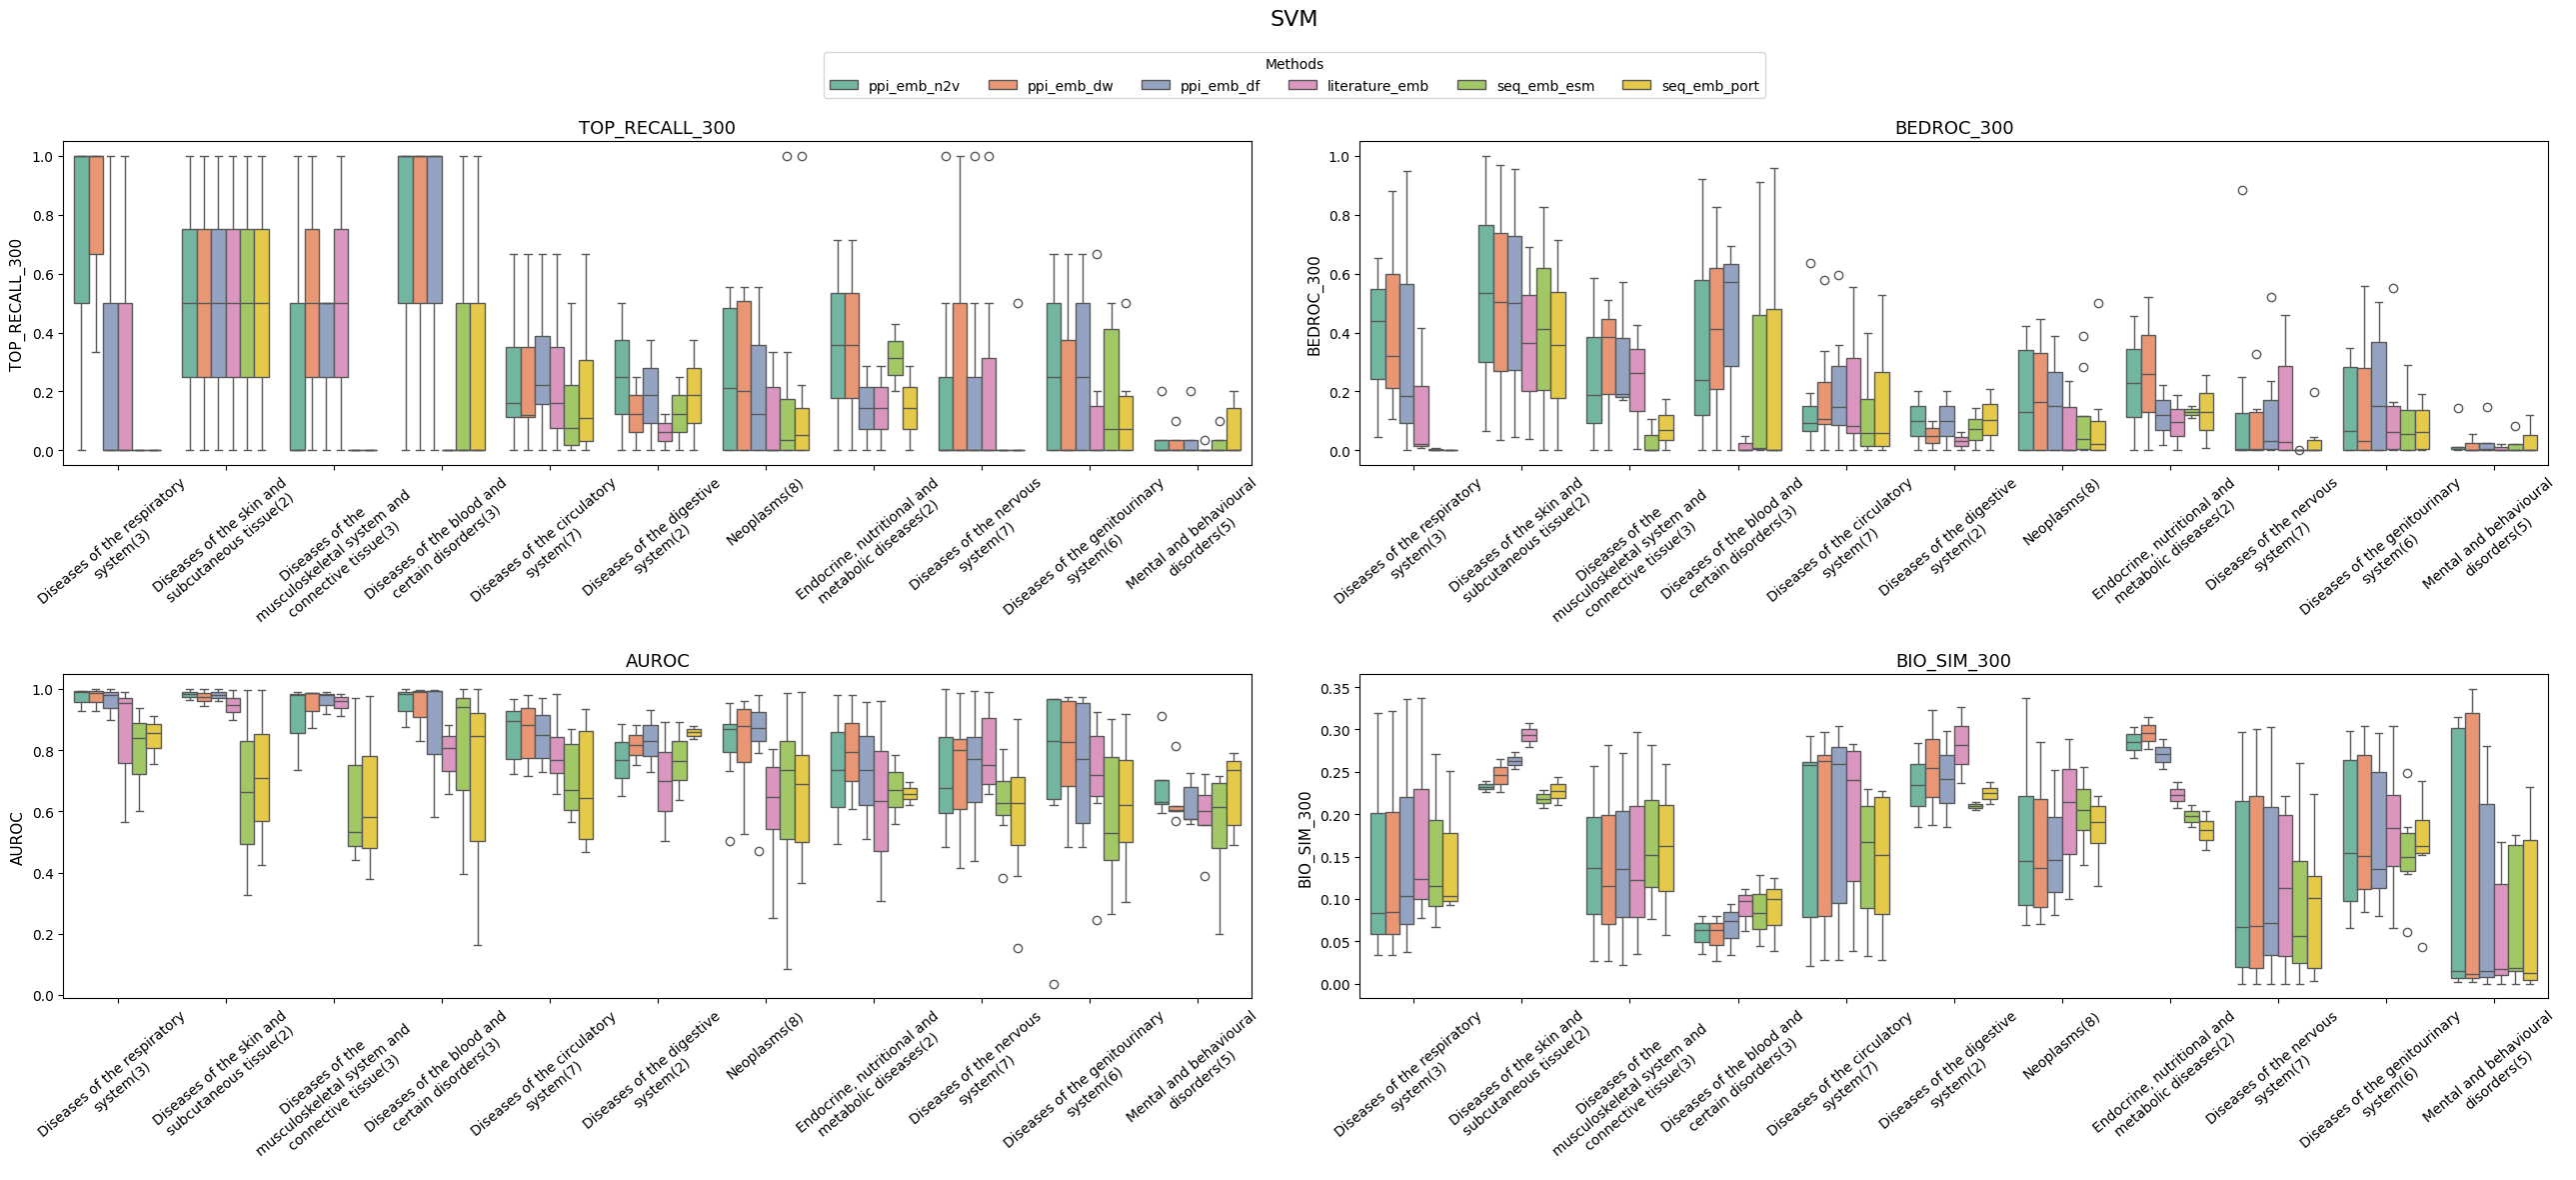

/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')
/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')
/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')
/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')


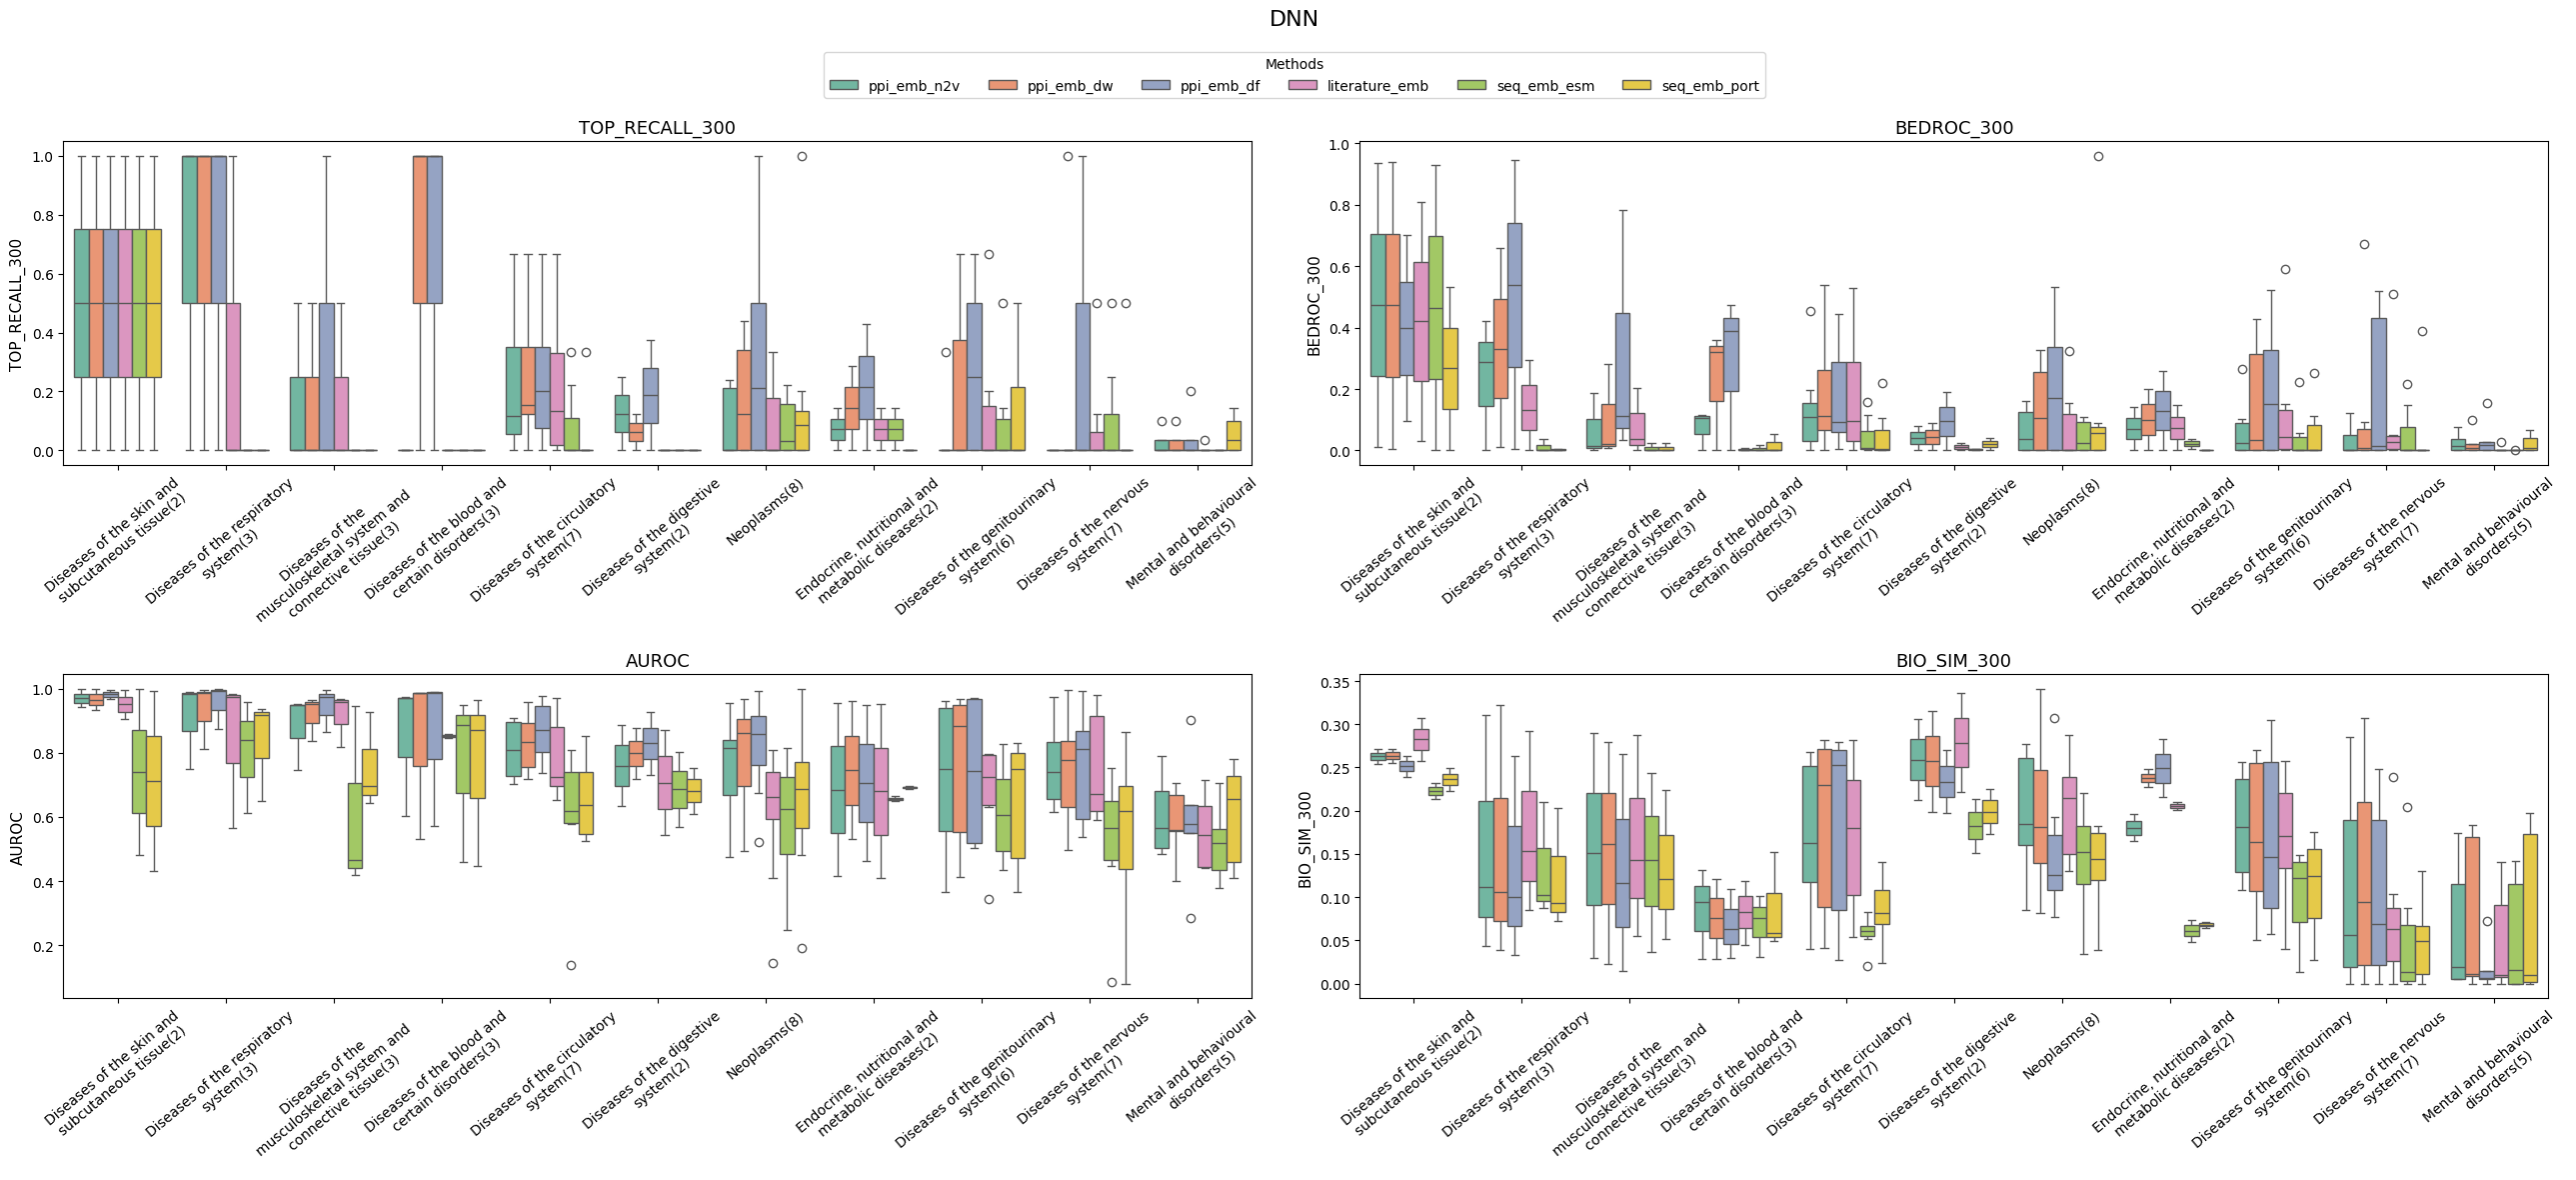

/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')
/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')
/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')
/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')


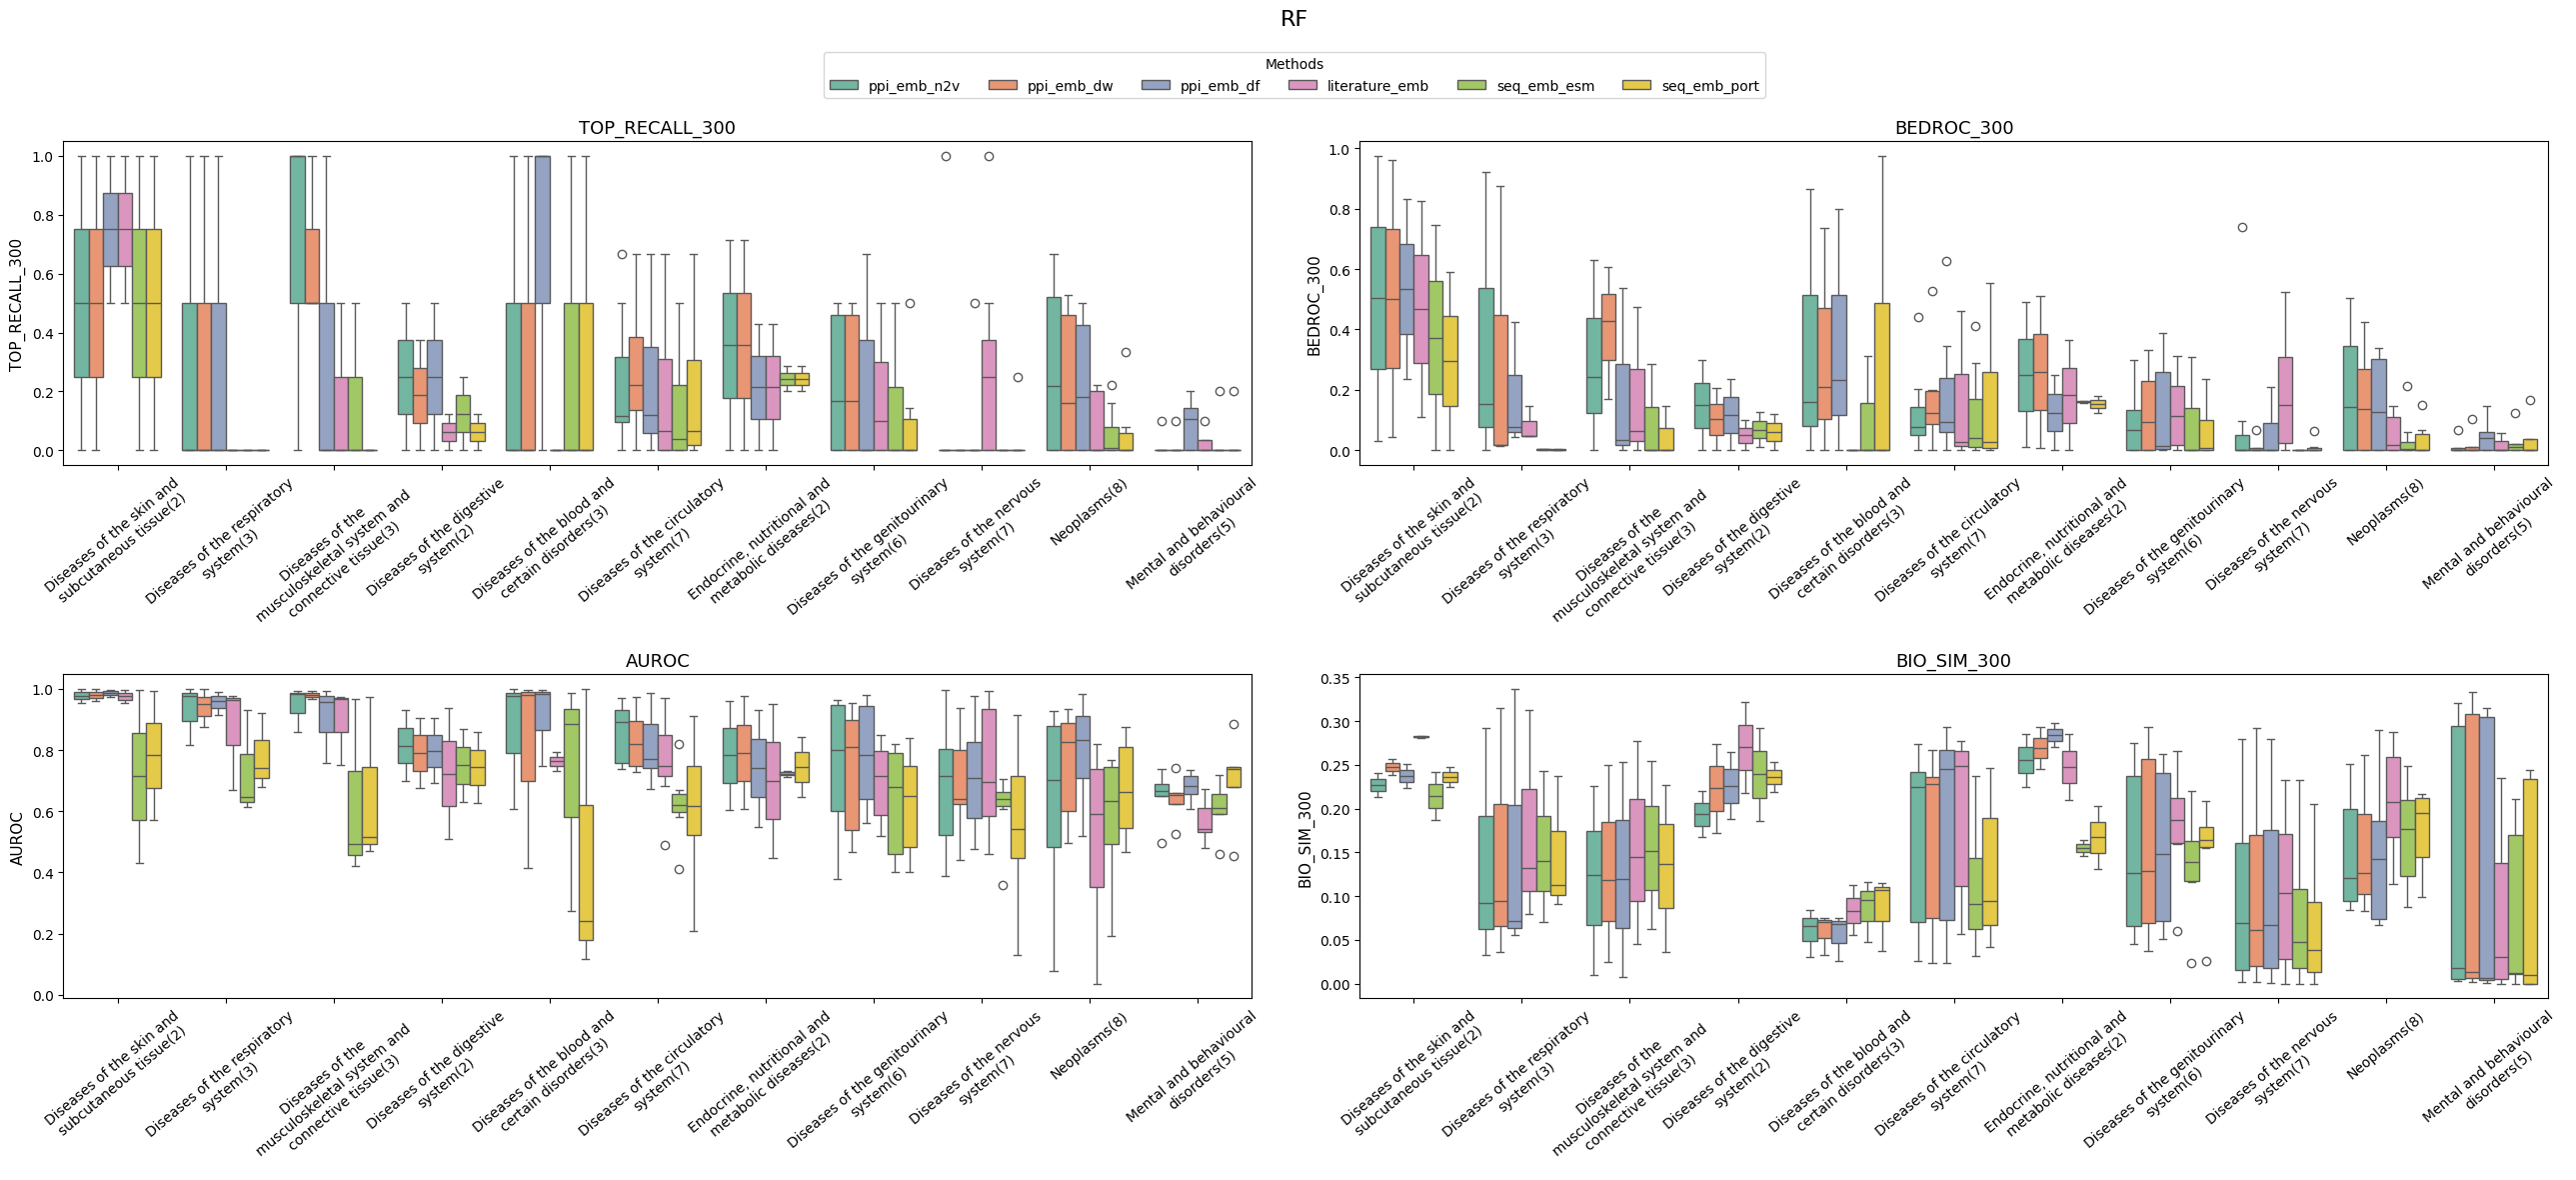

/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')
/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')
/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')
/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')


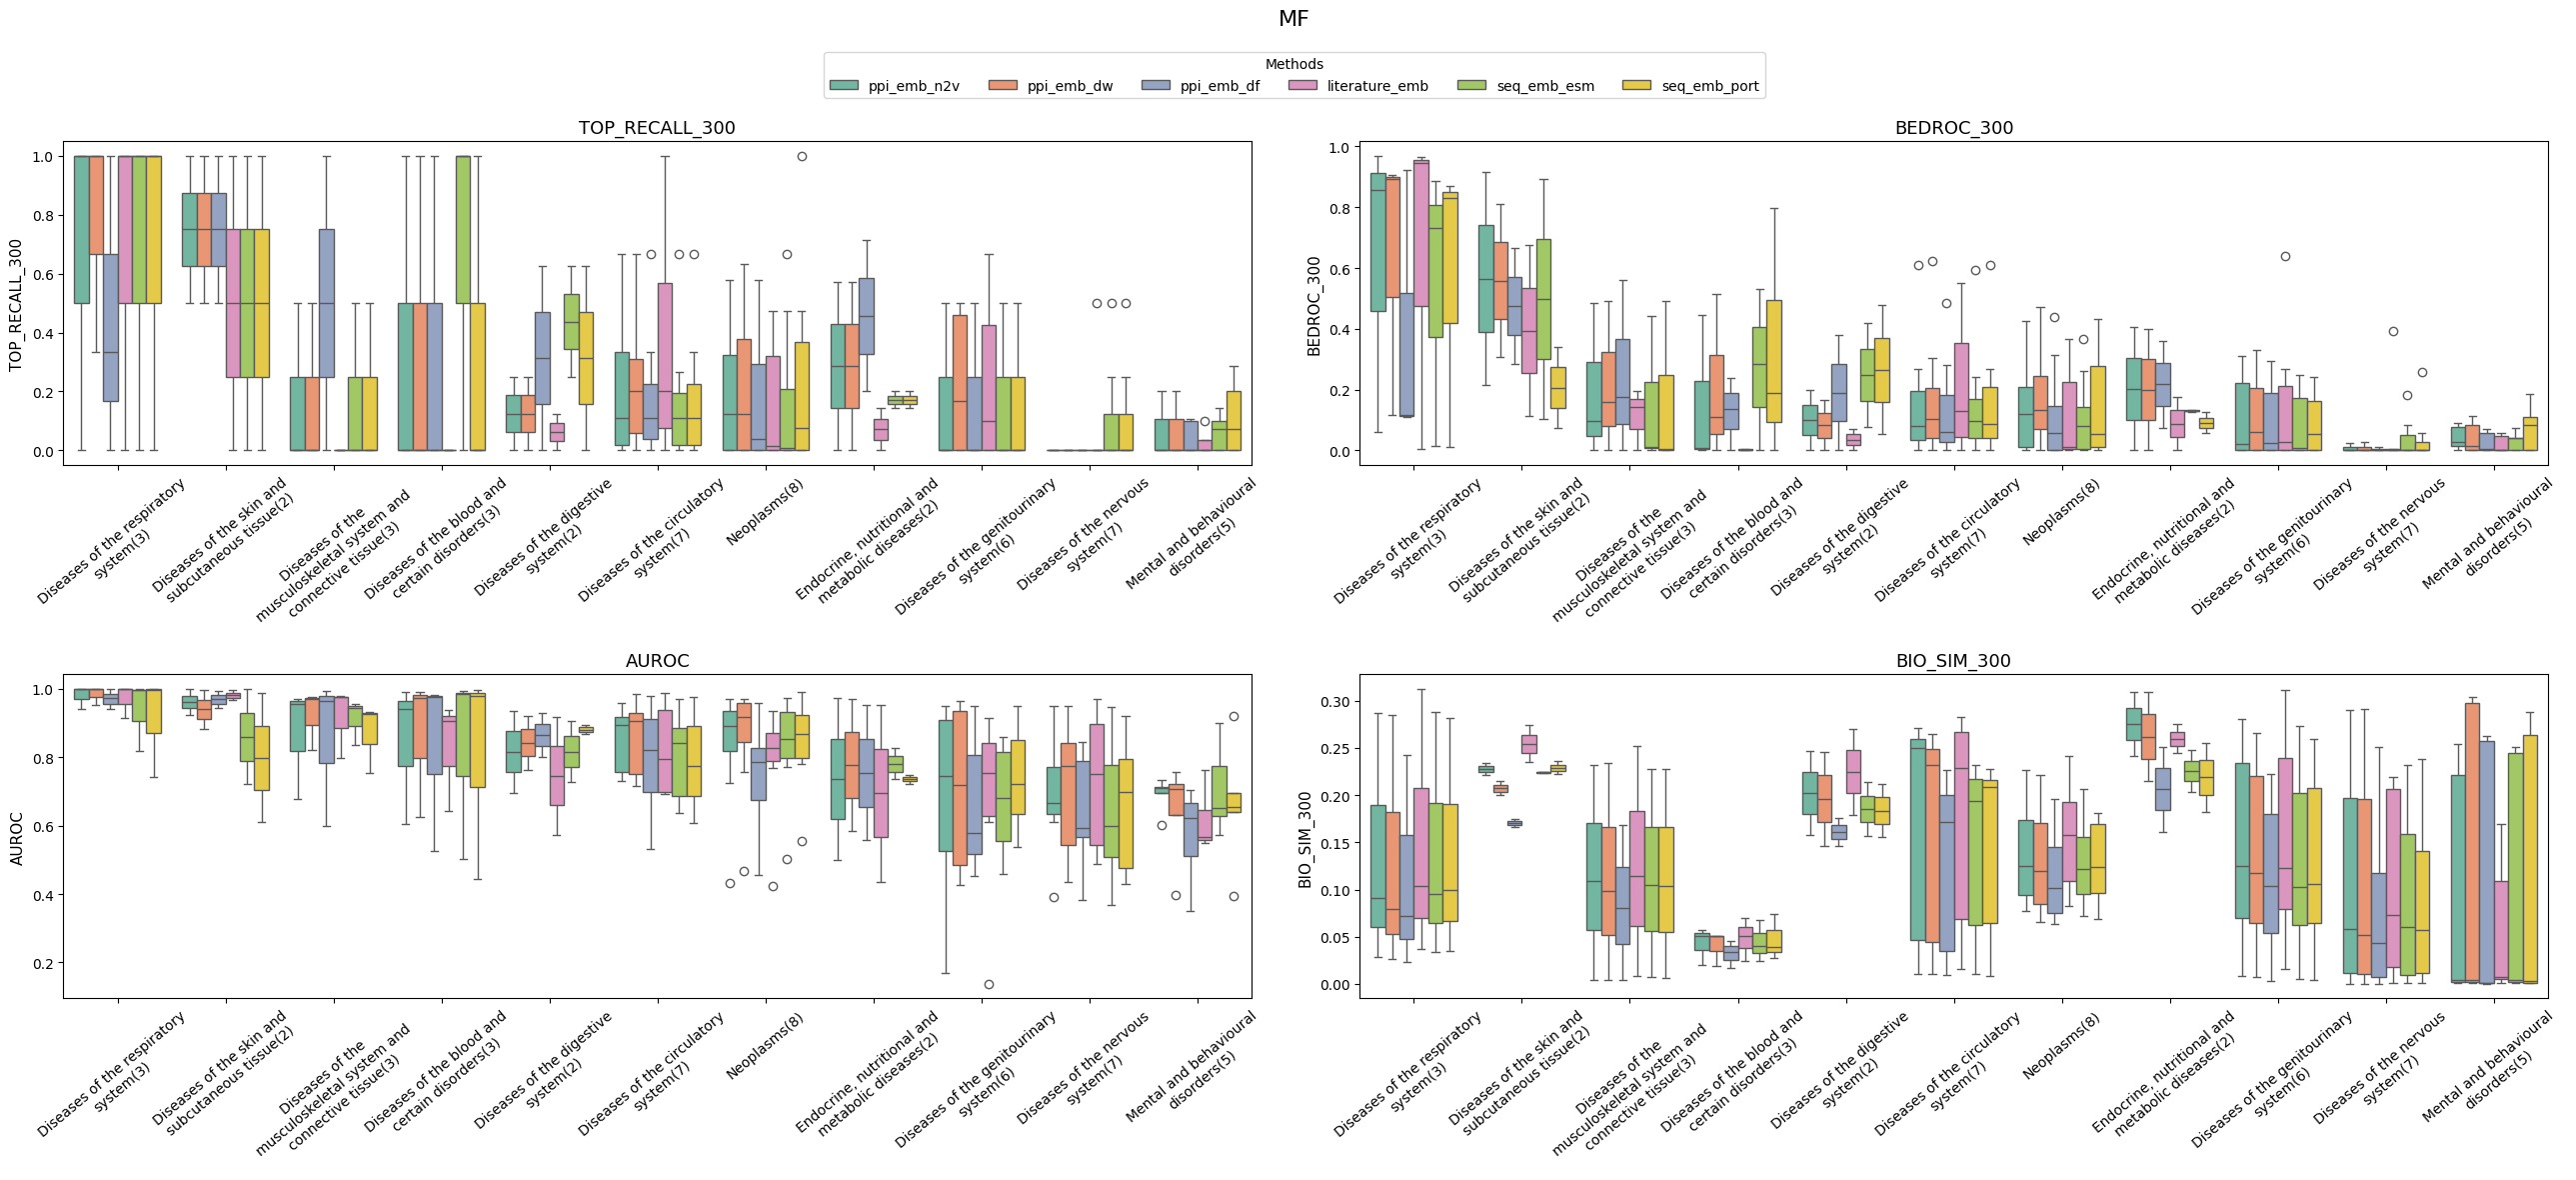

/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')
/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')
/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')
/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')


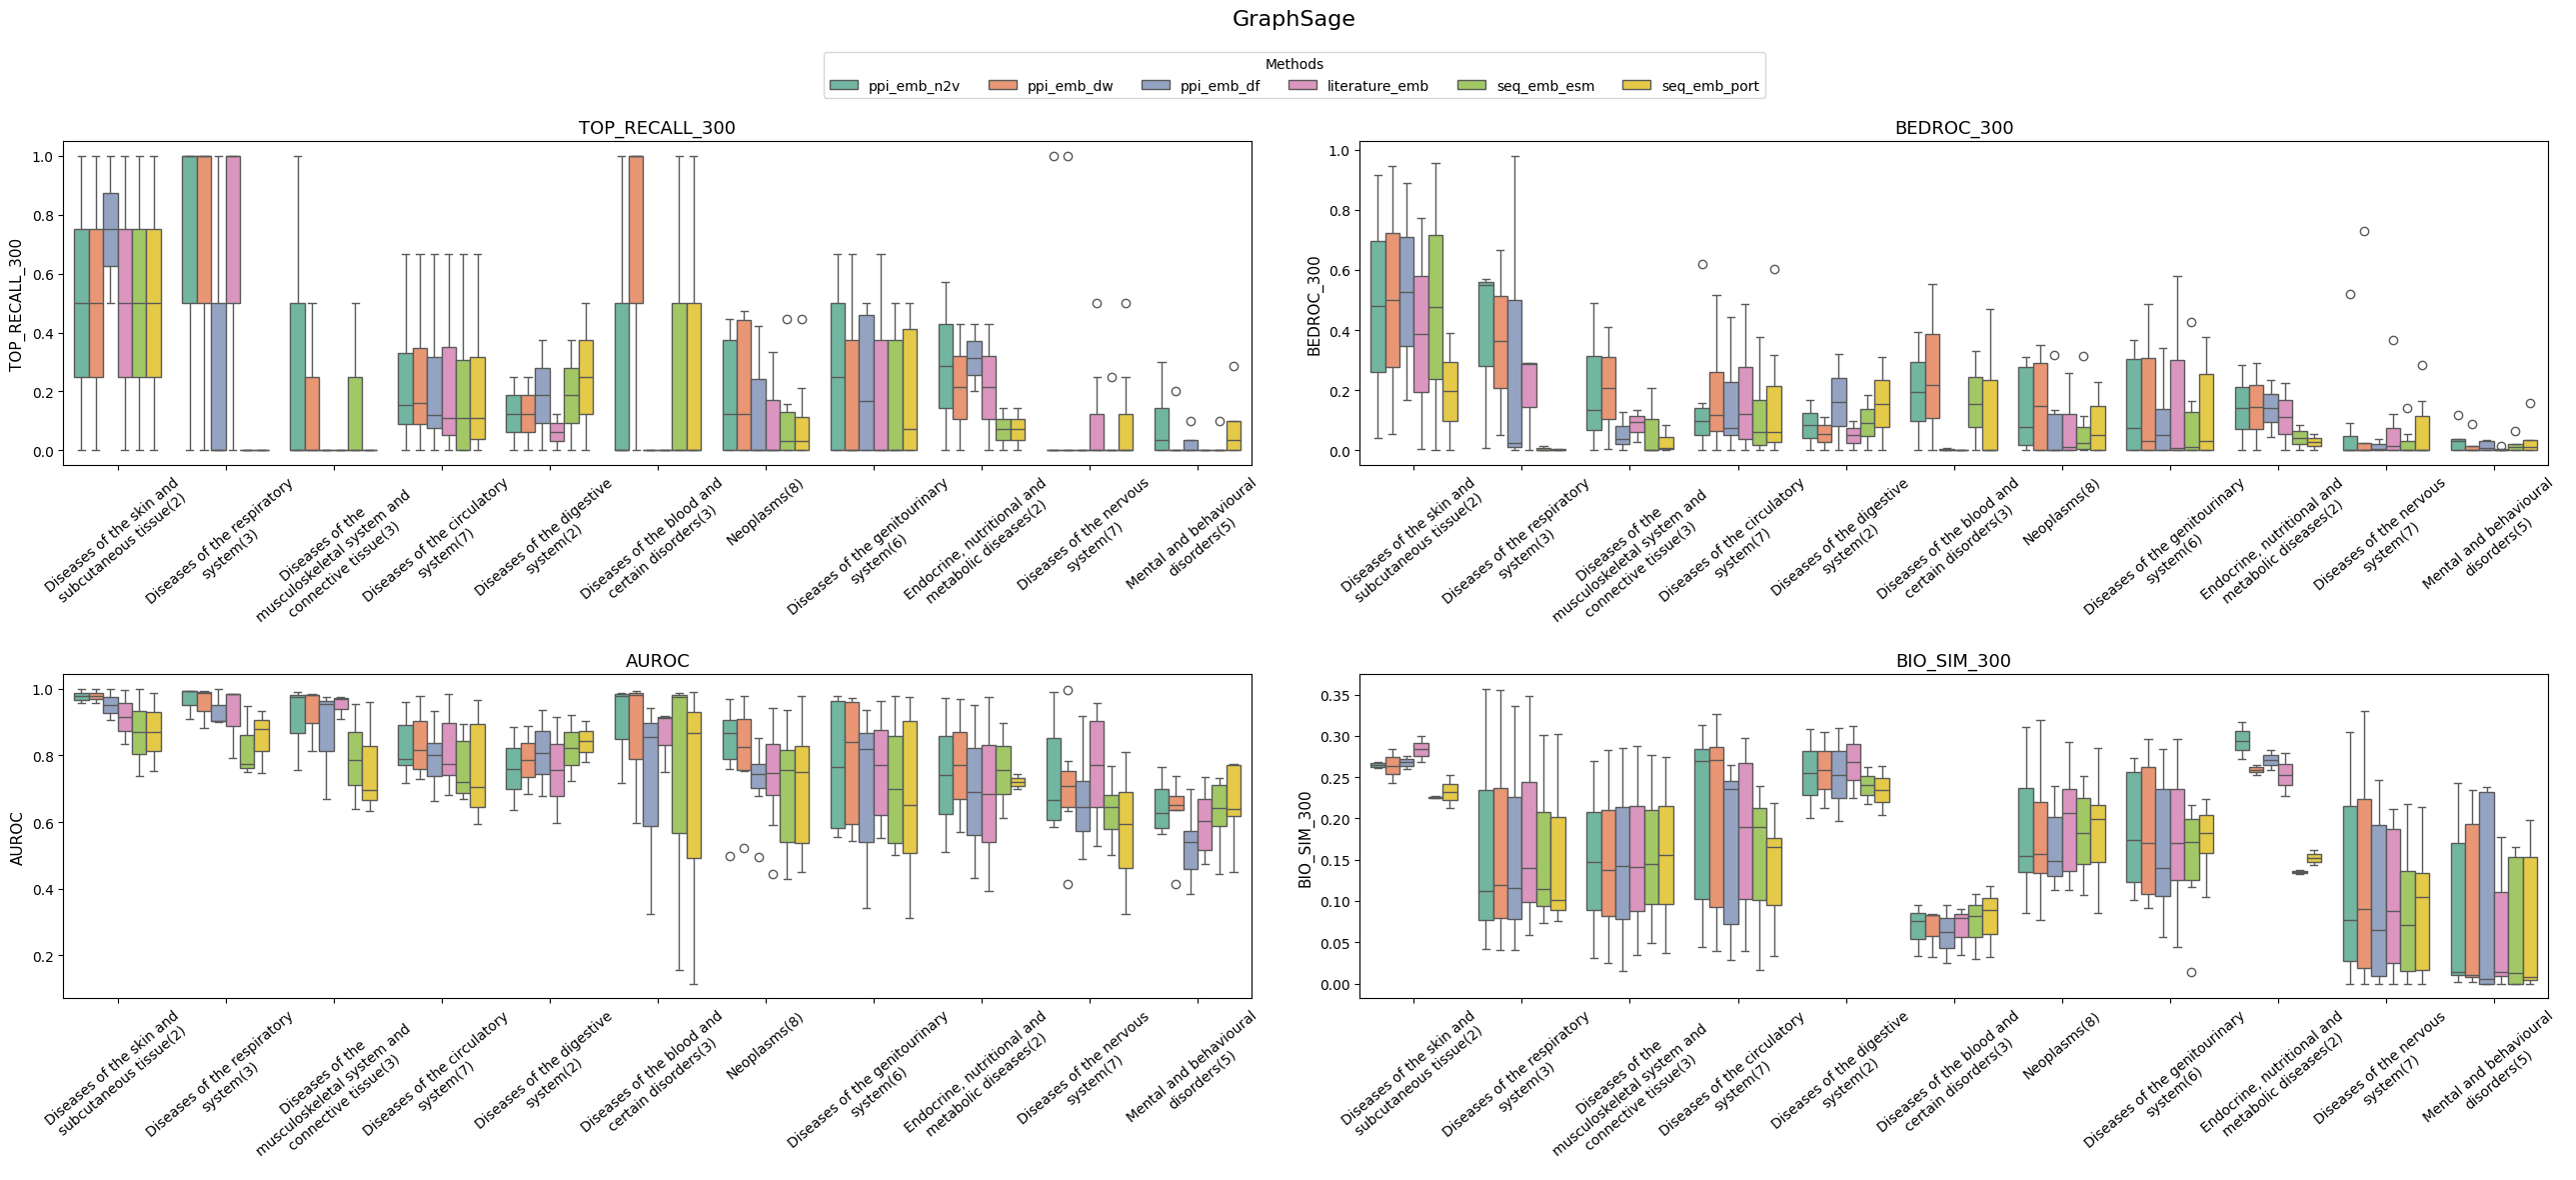

/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')
/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')
/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')
/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')


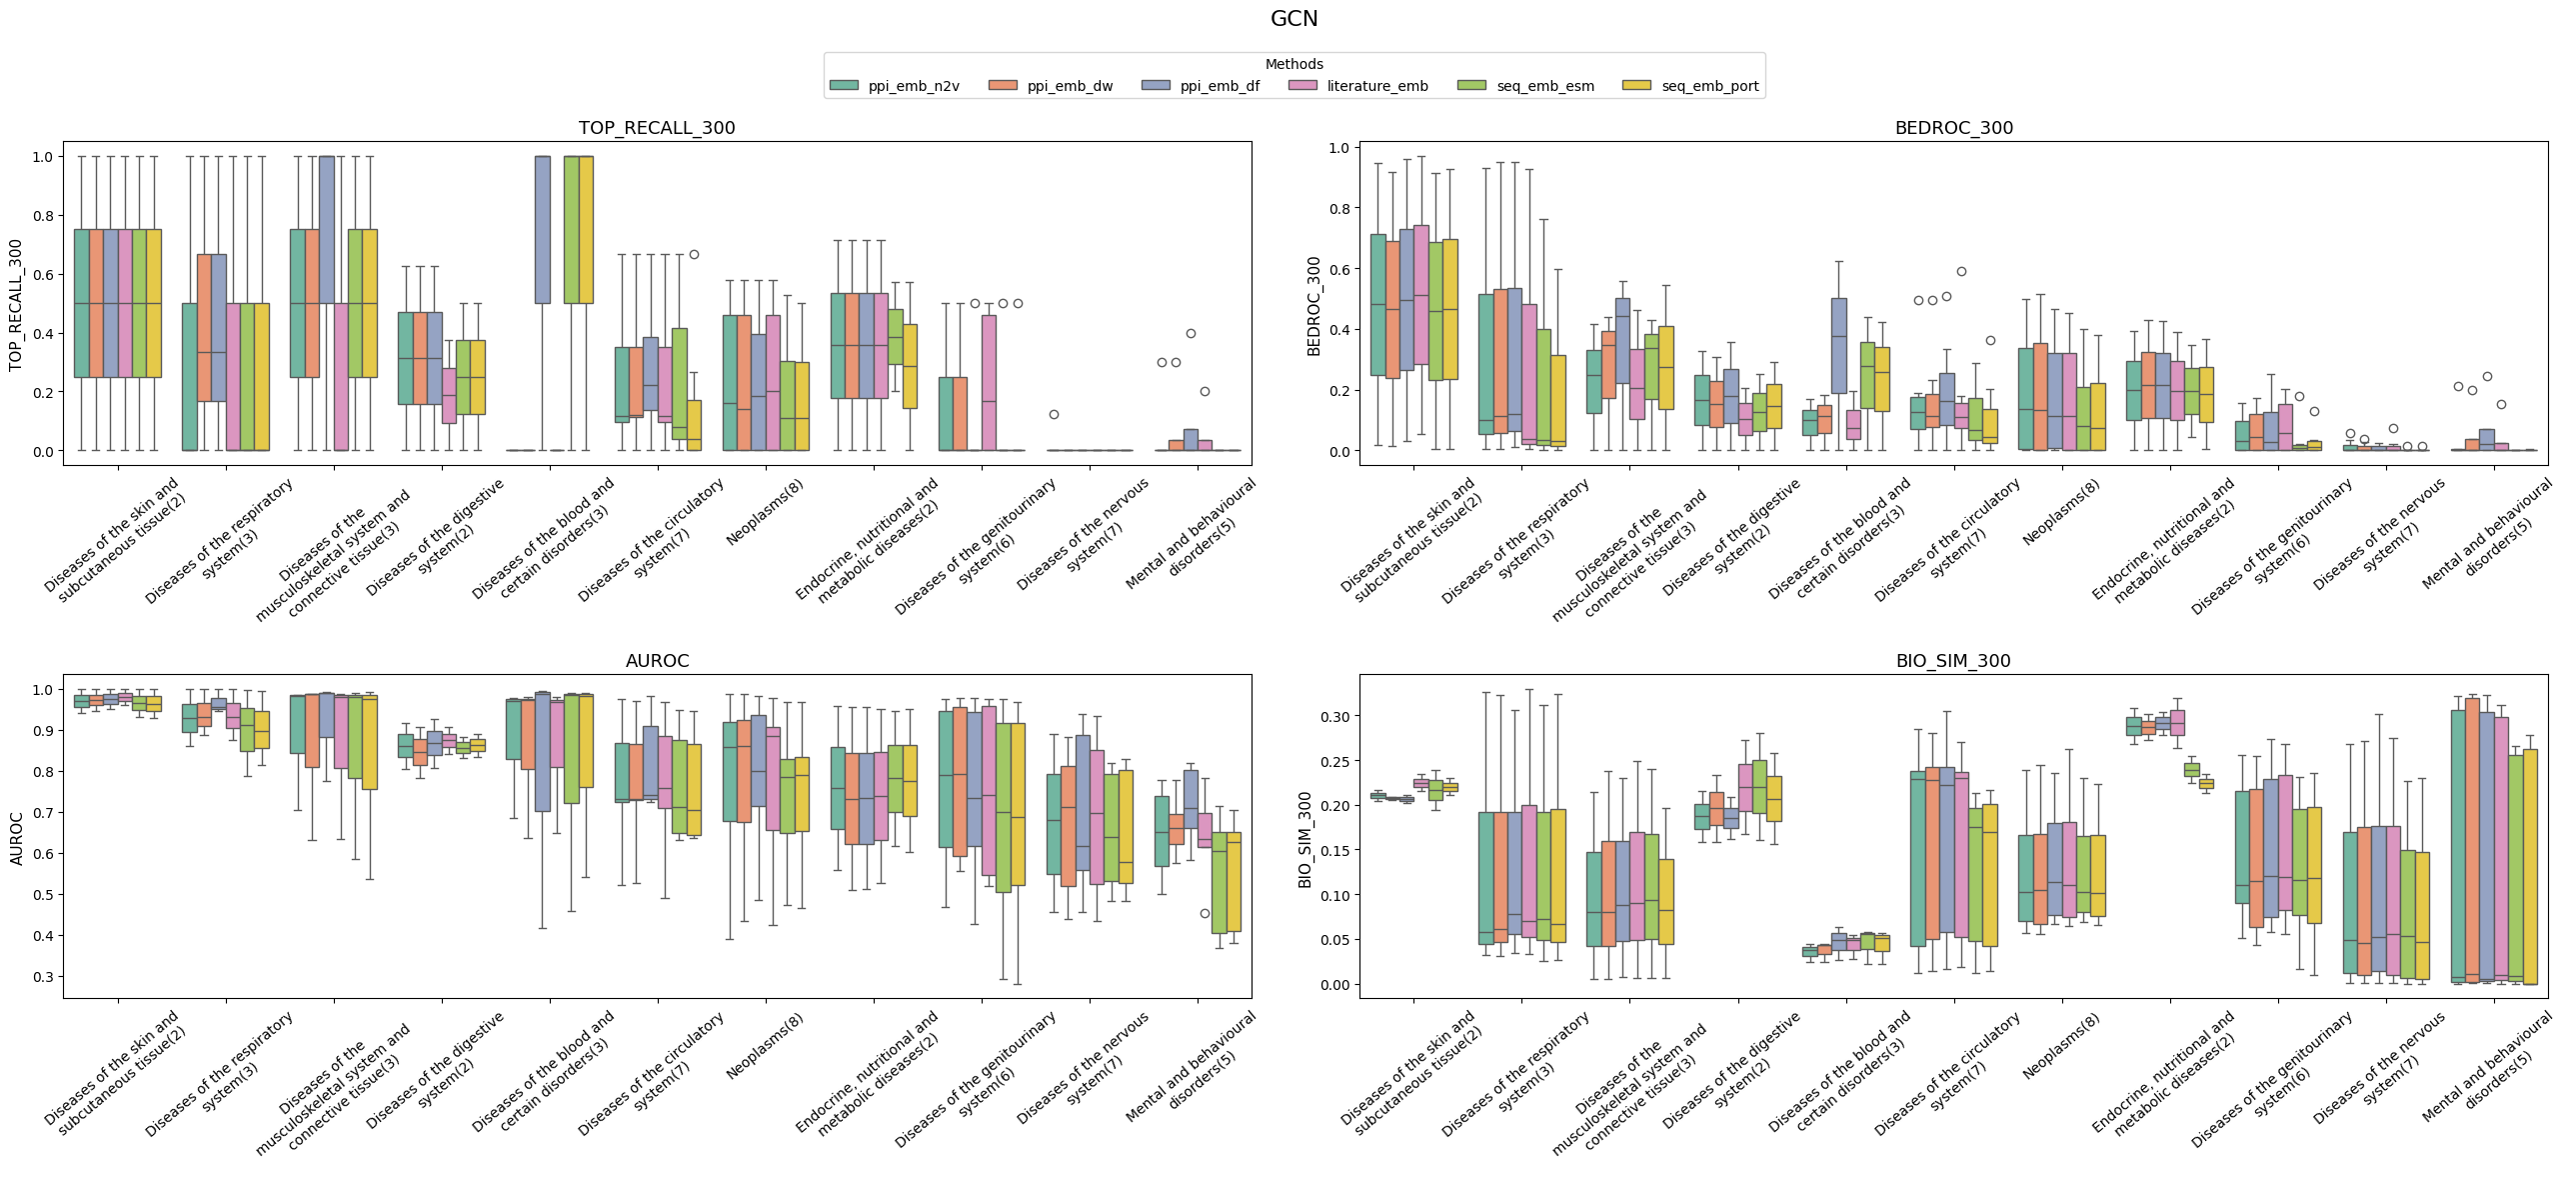

In [29]:
selected_features = ['ppi_emb_df','ppi_emb_dw', 'ppi_emb_n2v', 'literature_emb','seq_emb_esm', 'seq_emb_port']
models = ['df_gnn_occsvm_pred', '2019_nn_all_pred', '2019_rf_renamed_pred', '2019_mf_add_pred','graphsage', 'gcn']
model_name = ['SVM','DNN','RF','MF','GraphSage','GCN']
for i, model in enumerate(models):
    subresults = merged_df[(merged_df['setting']==model)&(merged_df['method'].isin(selected_features))]
    plot_metrics_boxplots_big(model_name[i], subresults, selected_metrics,['ppi_emb_n2v', 'ppi_emb_dw', 'ppi_emb_df', 'literature_emb','seq_emb_esm', 'seq_emb_port'])
    

## models

In [32]:
from matplotlib.backends.backend_pdf import PdfPages

pdf_path = "/itf-fi-ml/shared/users/ziyuzh/svm/model_comparison_plots.pdf"

selected_features = ['ppi_emb_df','ppi_emb_dw', 'ppi_emb_n2v', 'literature_emb','seq_emb_esm', 'seq_emb_port']
models = ['df_gnn_occsvm_pred', '2019_nn_all_pred', '2019_rf_renamed_pred', '2019_mf_add_pred','graphsage', 'gcn']
model_name = ['SVM','DNN','RF','MF','GraphSage','GCN']
method_mapping = dict(zip(models,model_name))

with PdfPages(pdf_path) as pdf:
    for i, feature in enumerate(selected_features):

        subresults = merged_df[(merged_df['method']==feature)&(merged_df['setting'].isin(models))].copy()
        subresults['method'] = subresults['setting'].map(method_mapping)

        fig = plot_metrics_boxplots_big(feature, subresults, selected_metrics,model_name,return_fig=True)

        pdf.savefig(fig)
        plt.close(fig)   # 🔑 important to avoid memory issues

/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')
/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')
/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')
/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')
/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be us

/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')
/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')
/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')
/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')


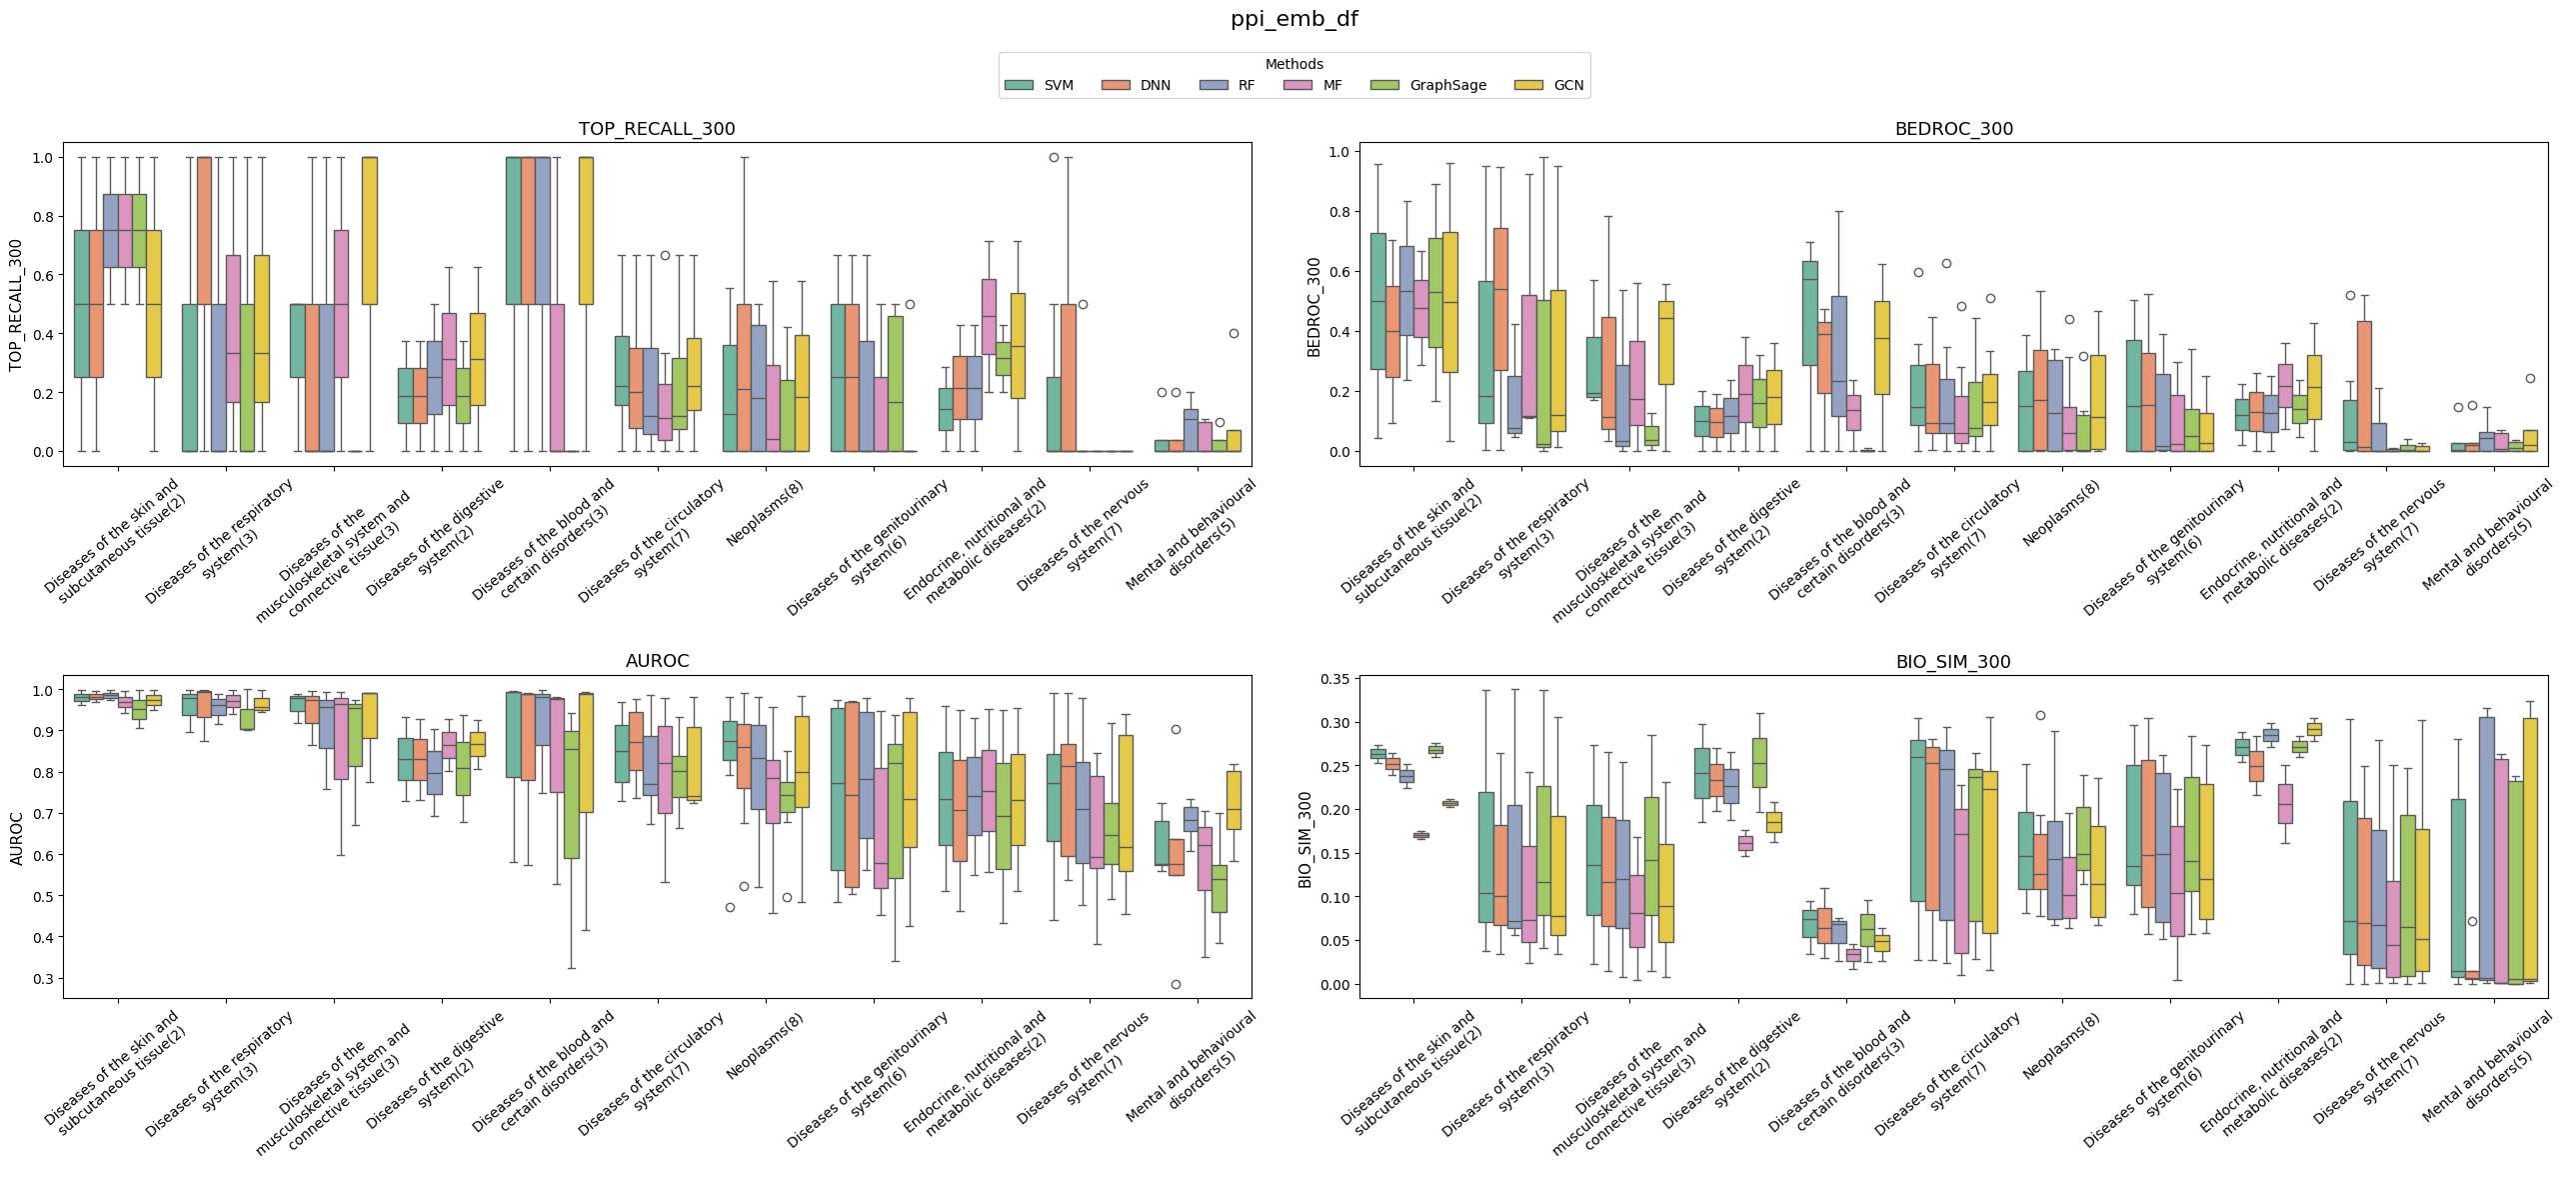

/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')
/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')
/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')
/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')


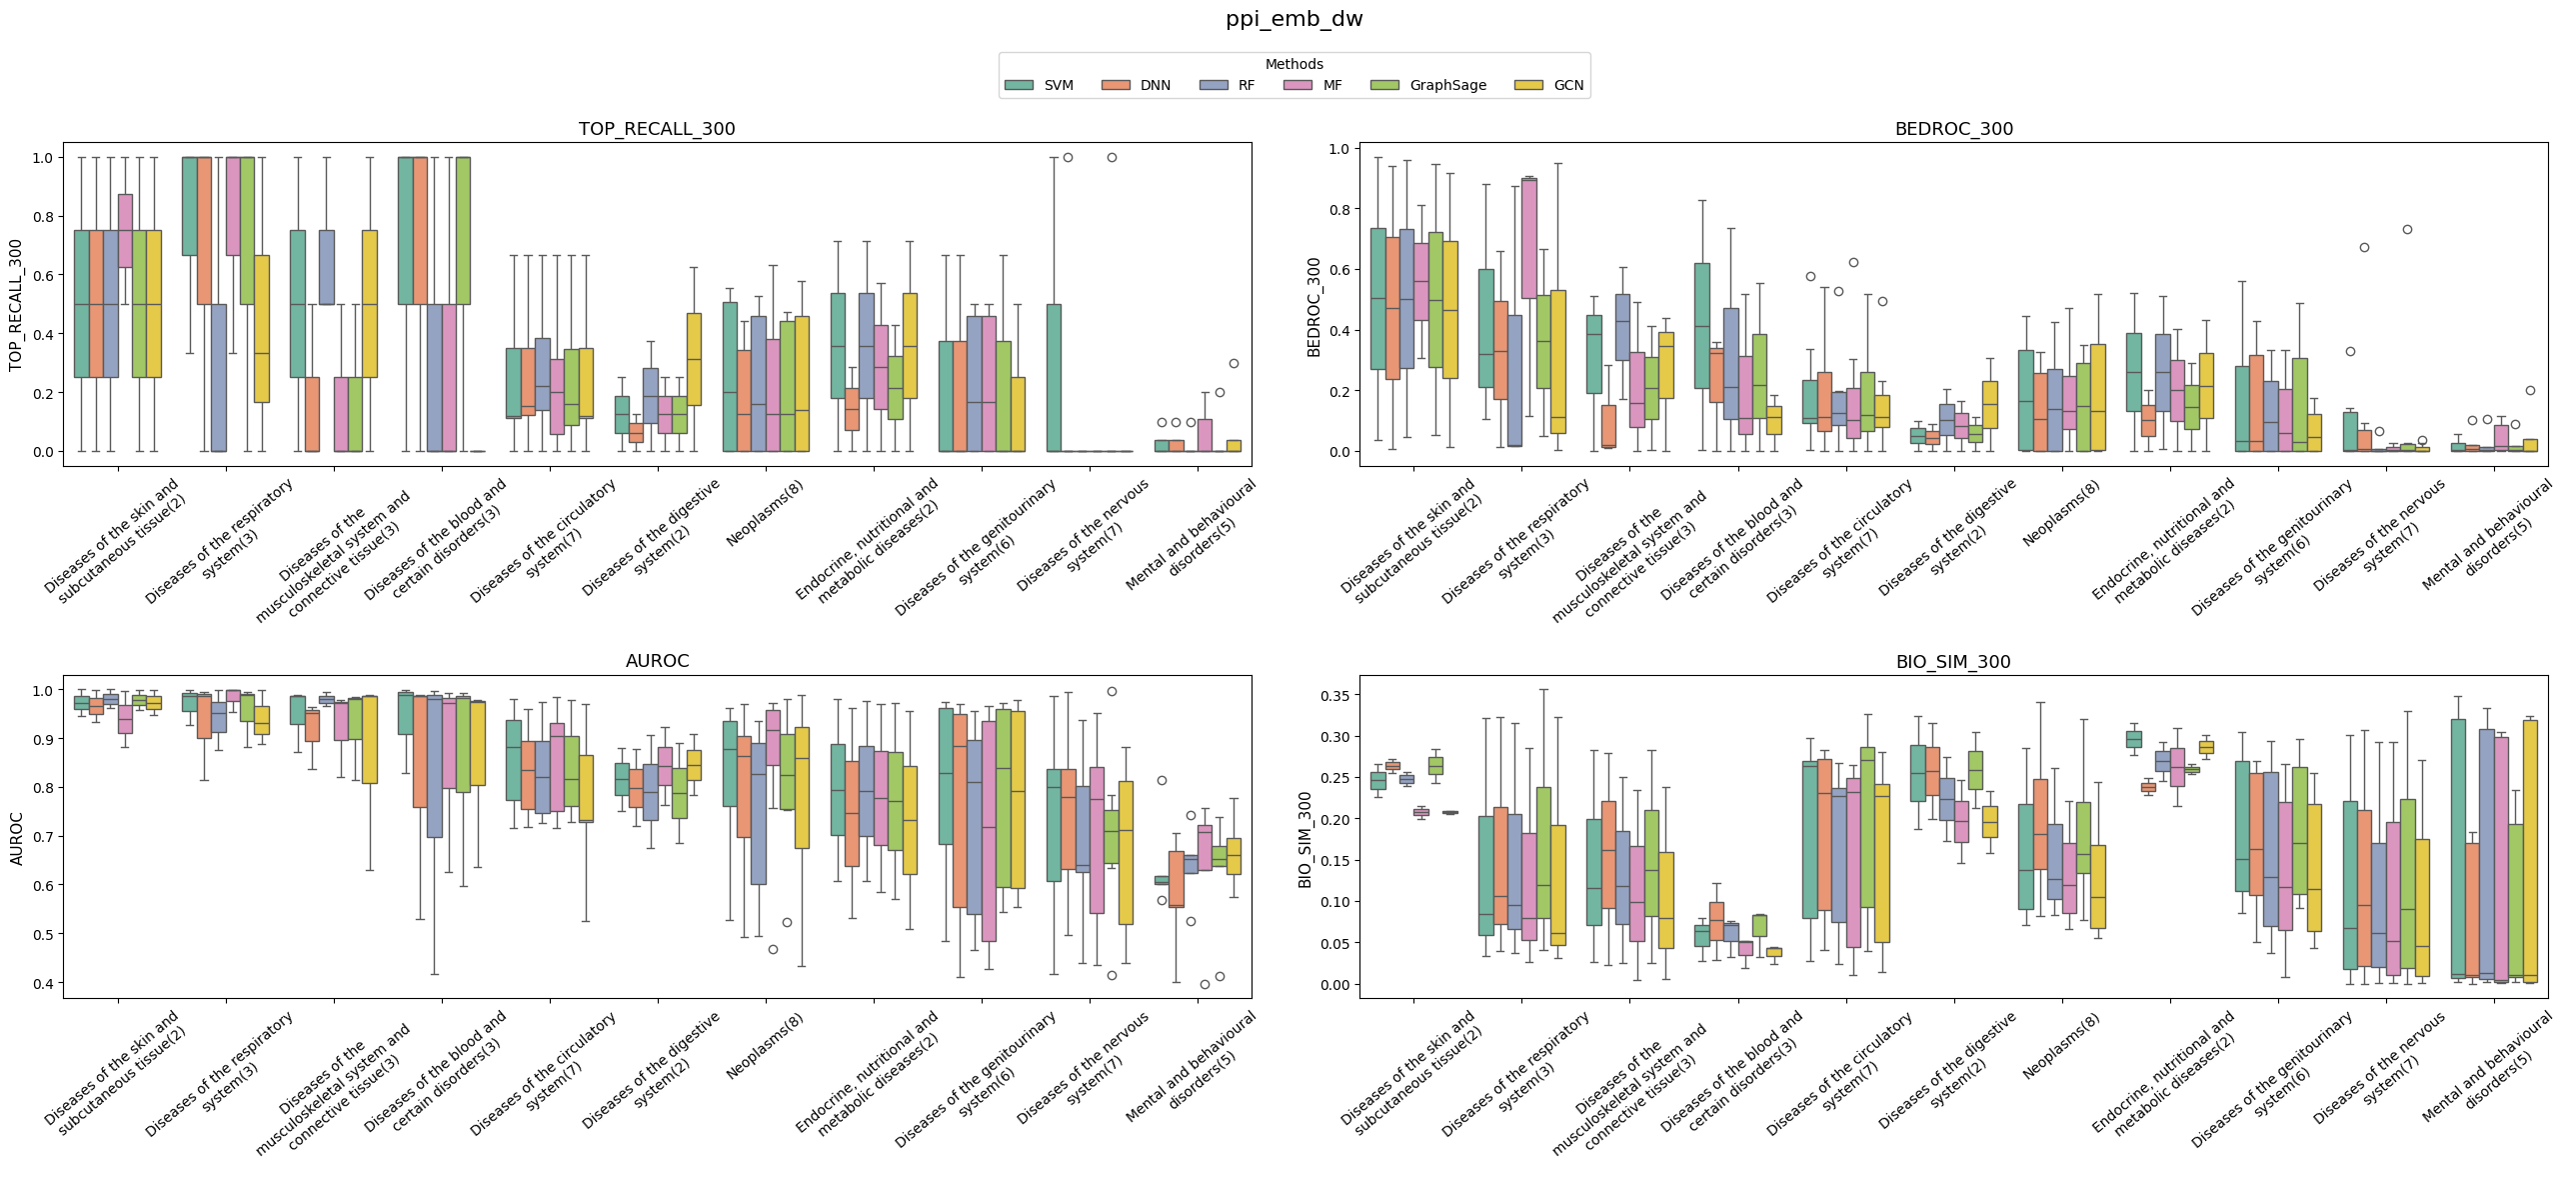

/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')
/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')
/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')
/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')


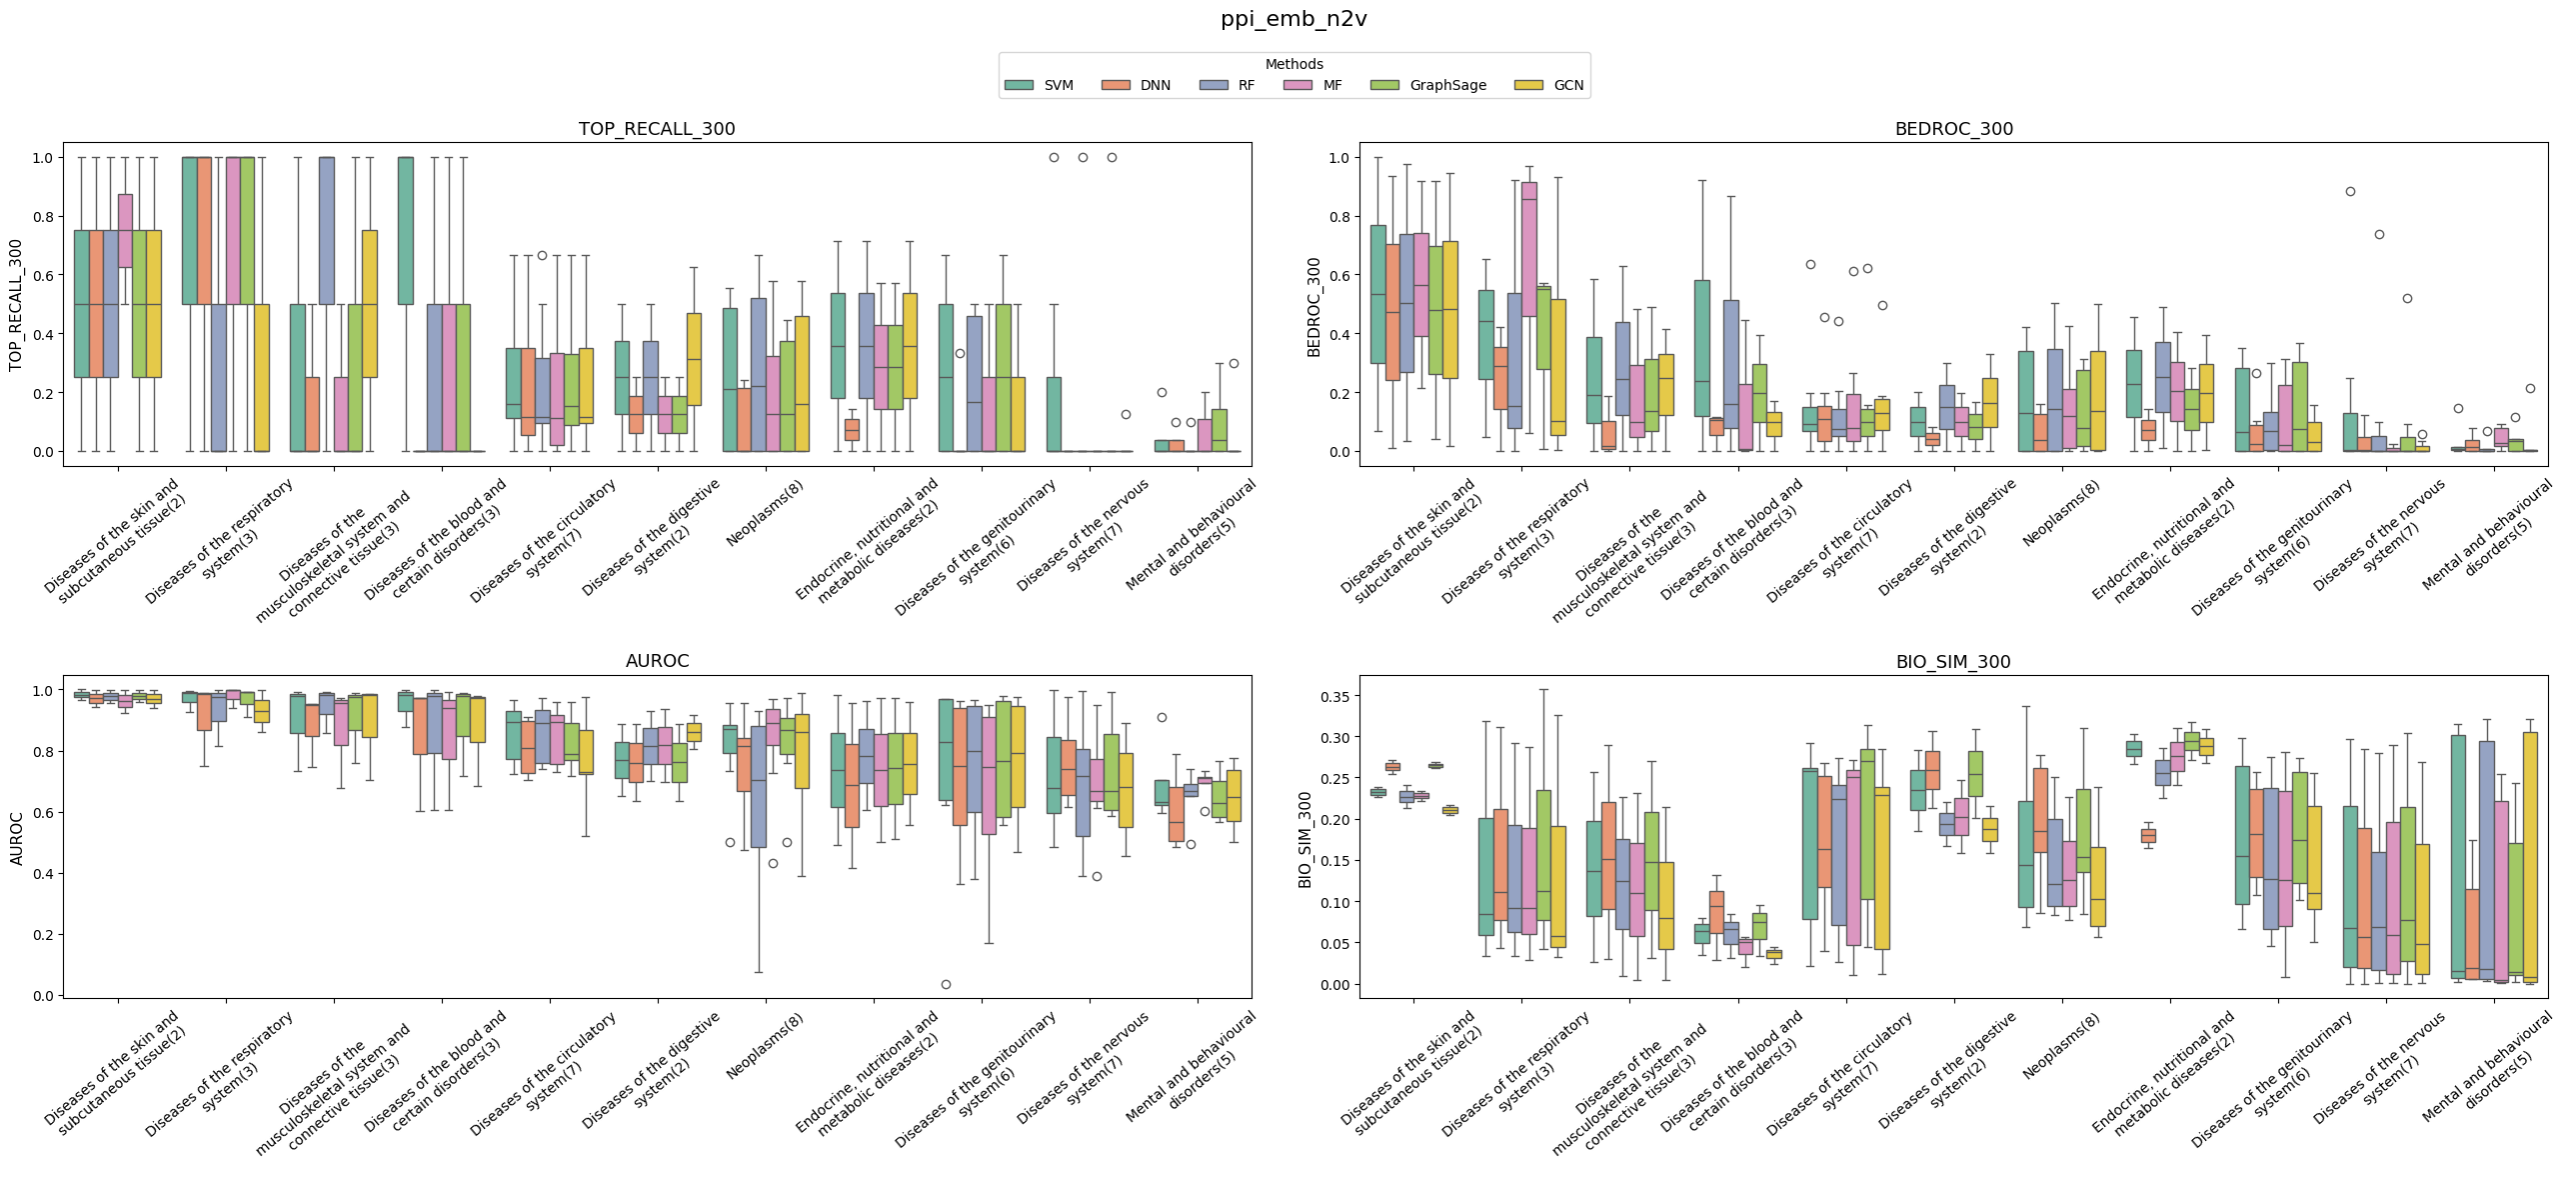

/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')
/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')
/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')
/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')


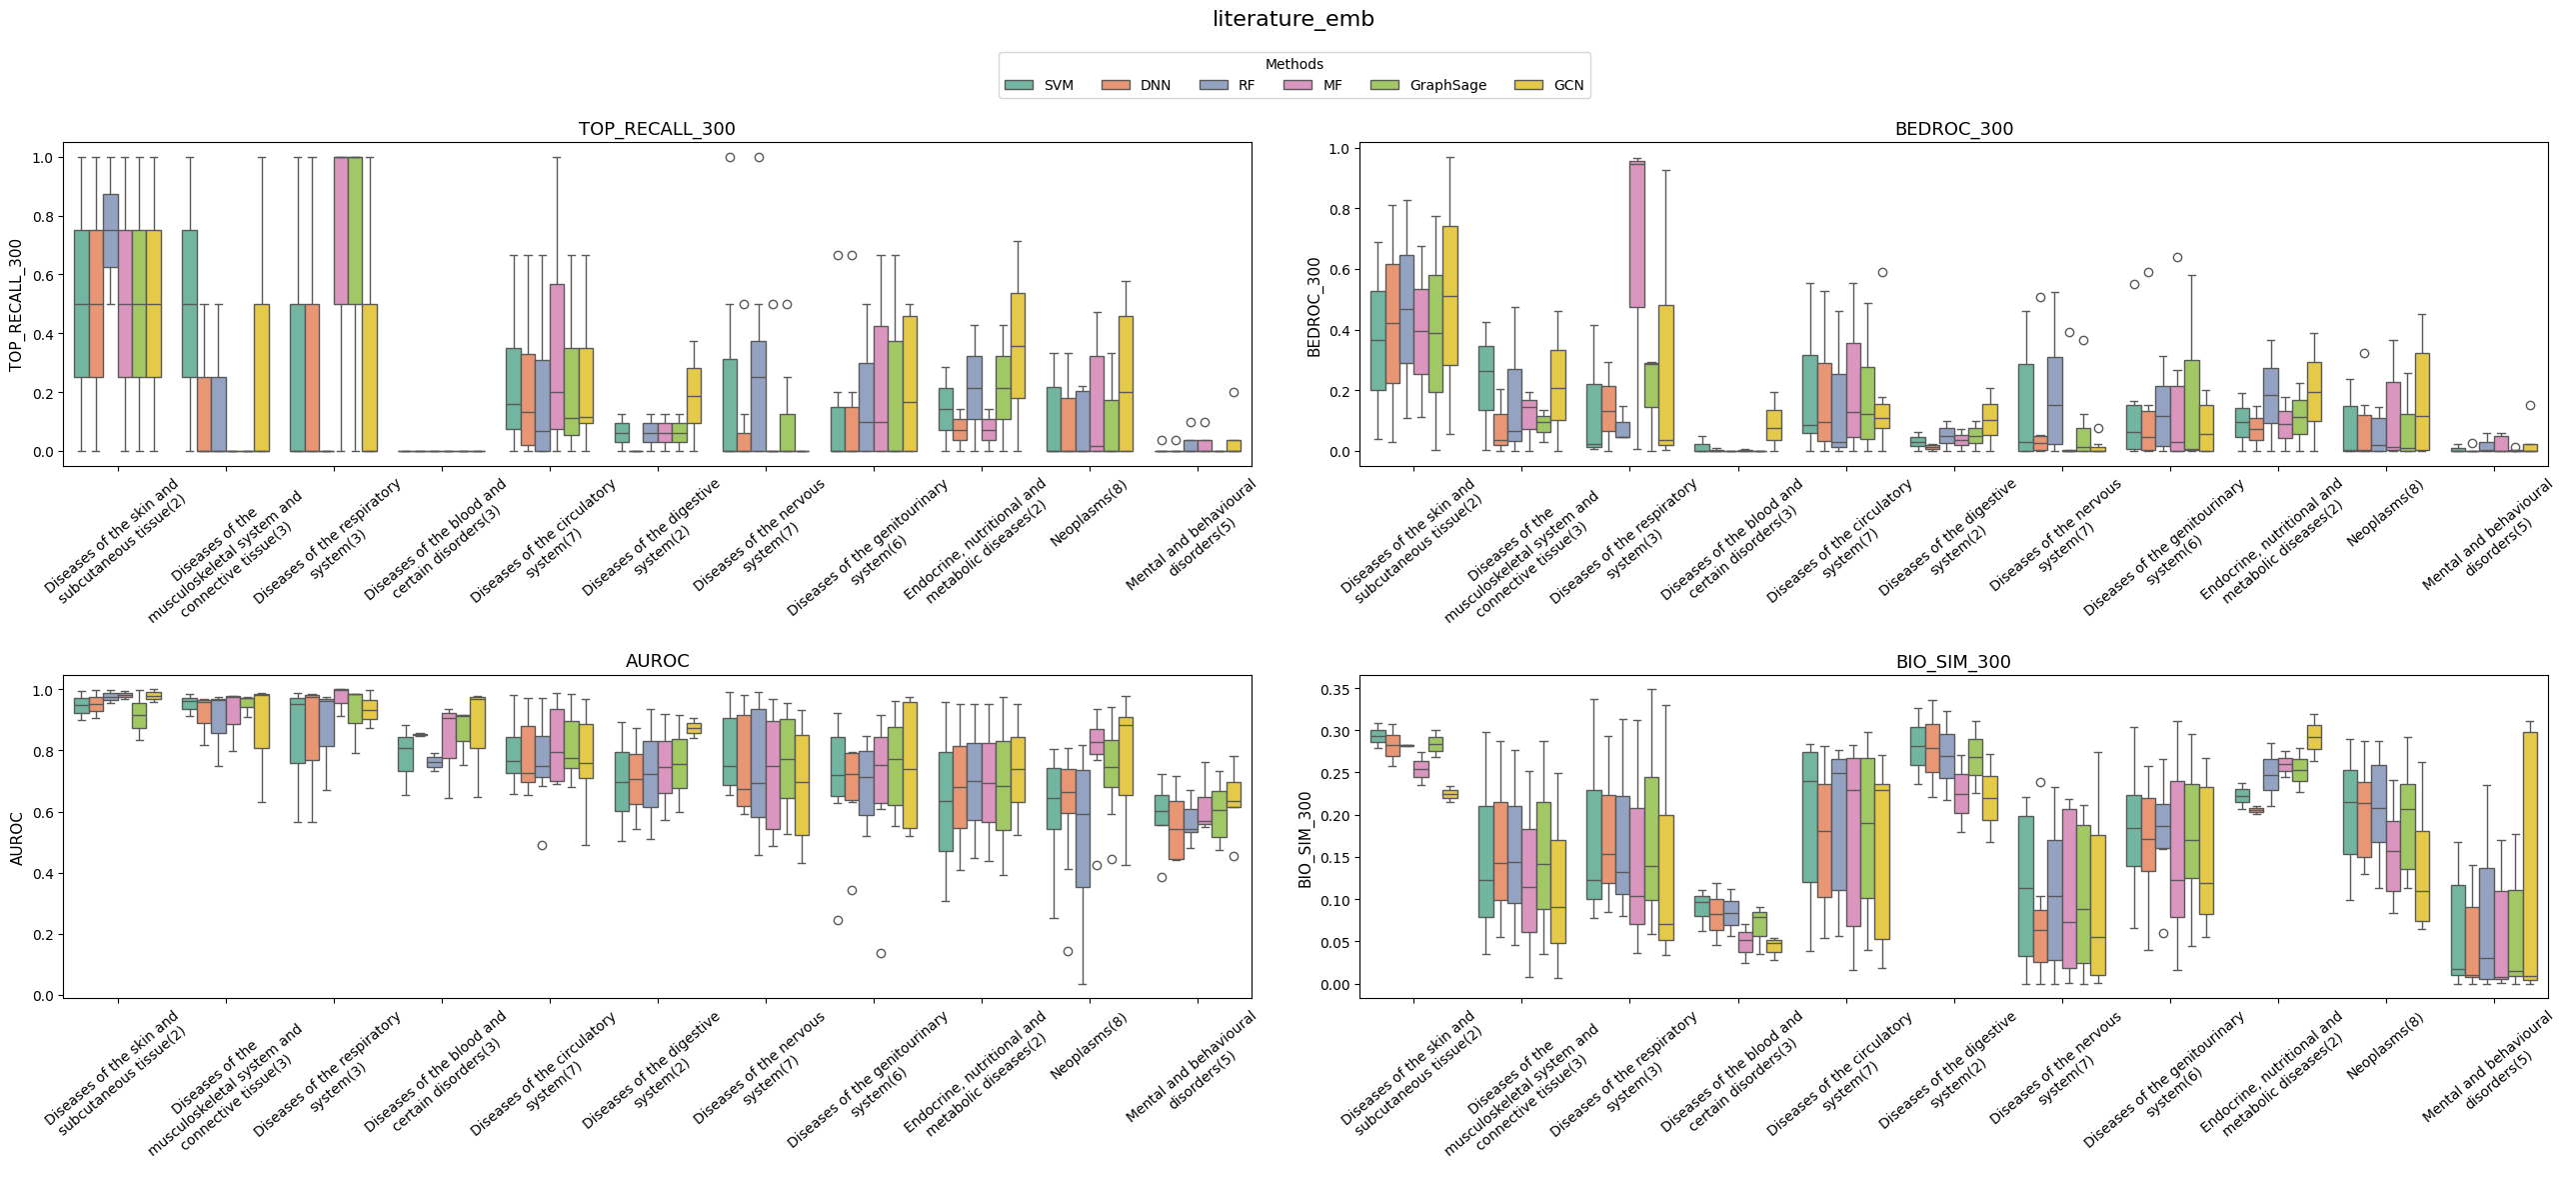

/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')
/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')
/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')
/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')


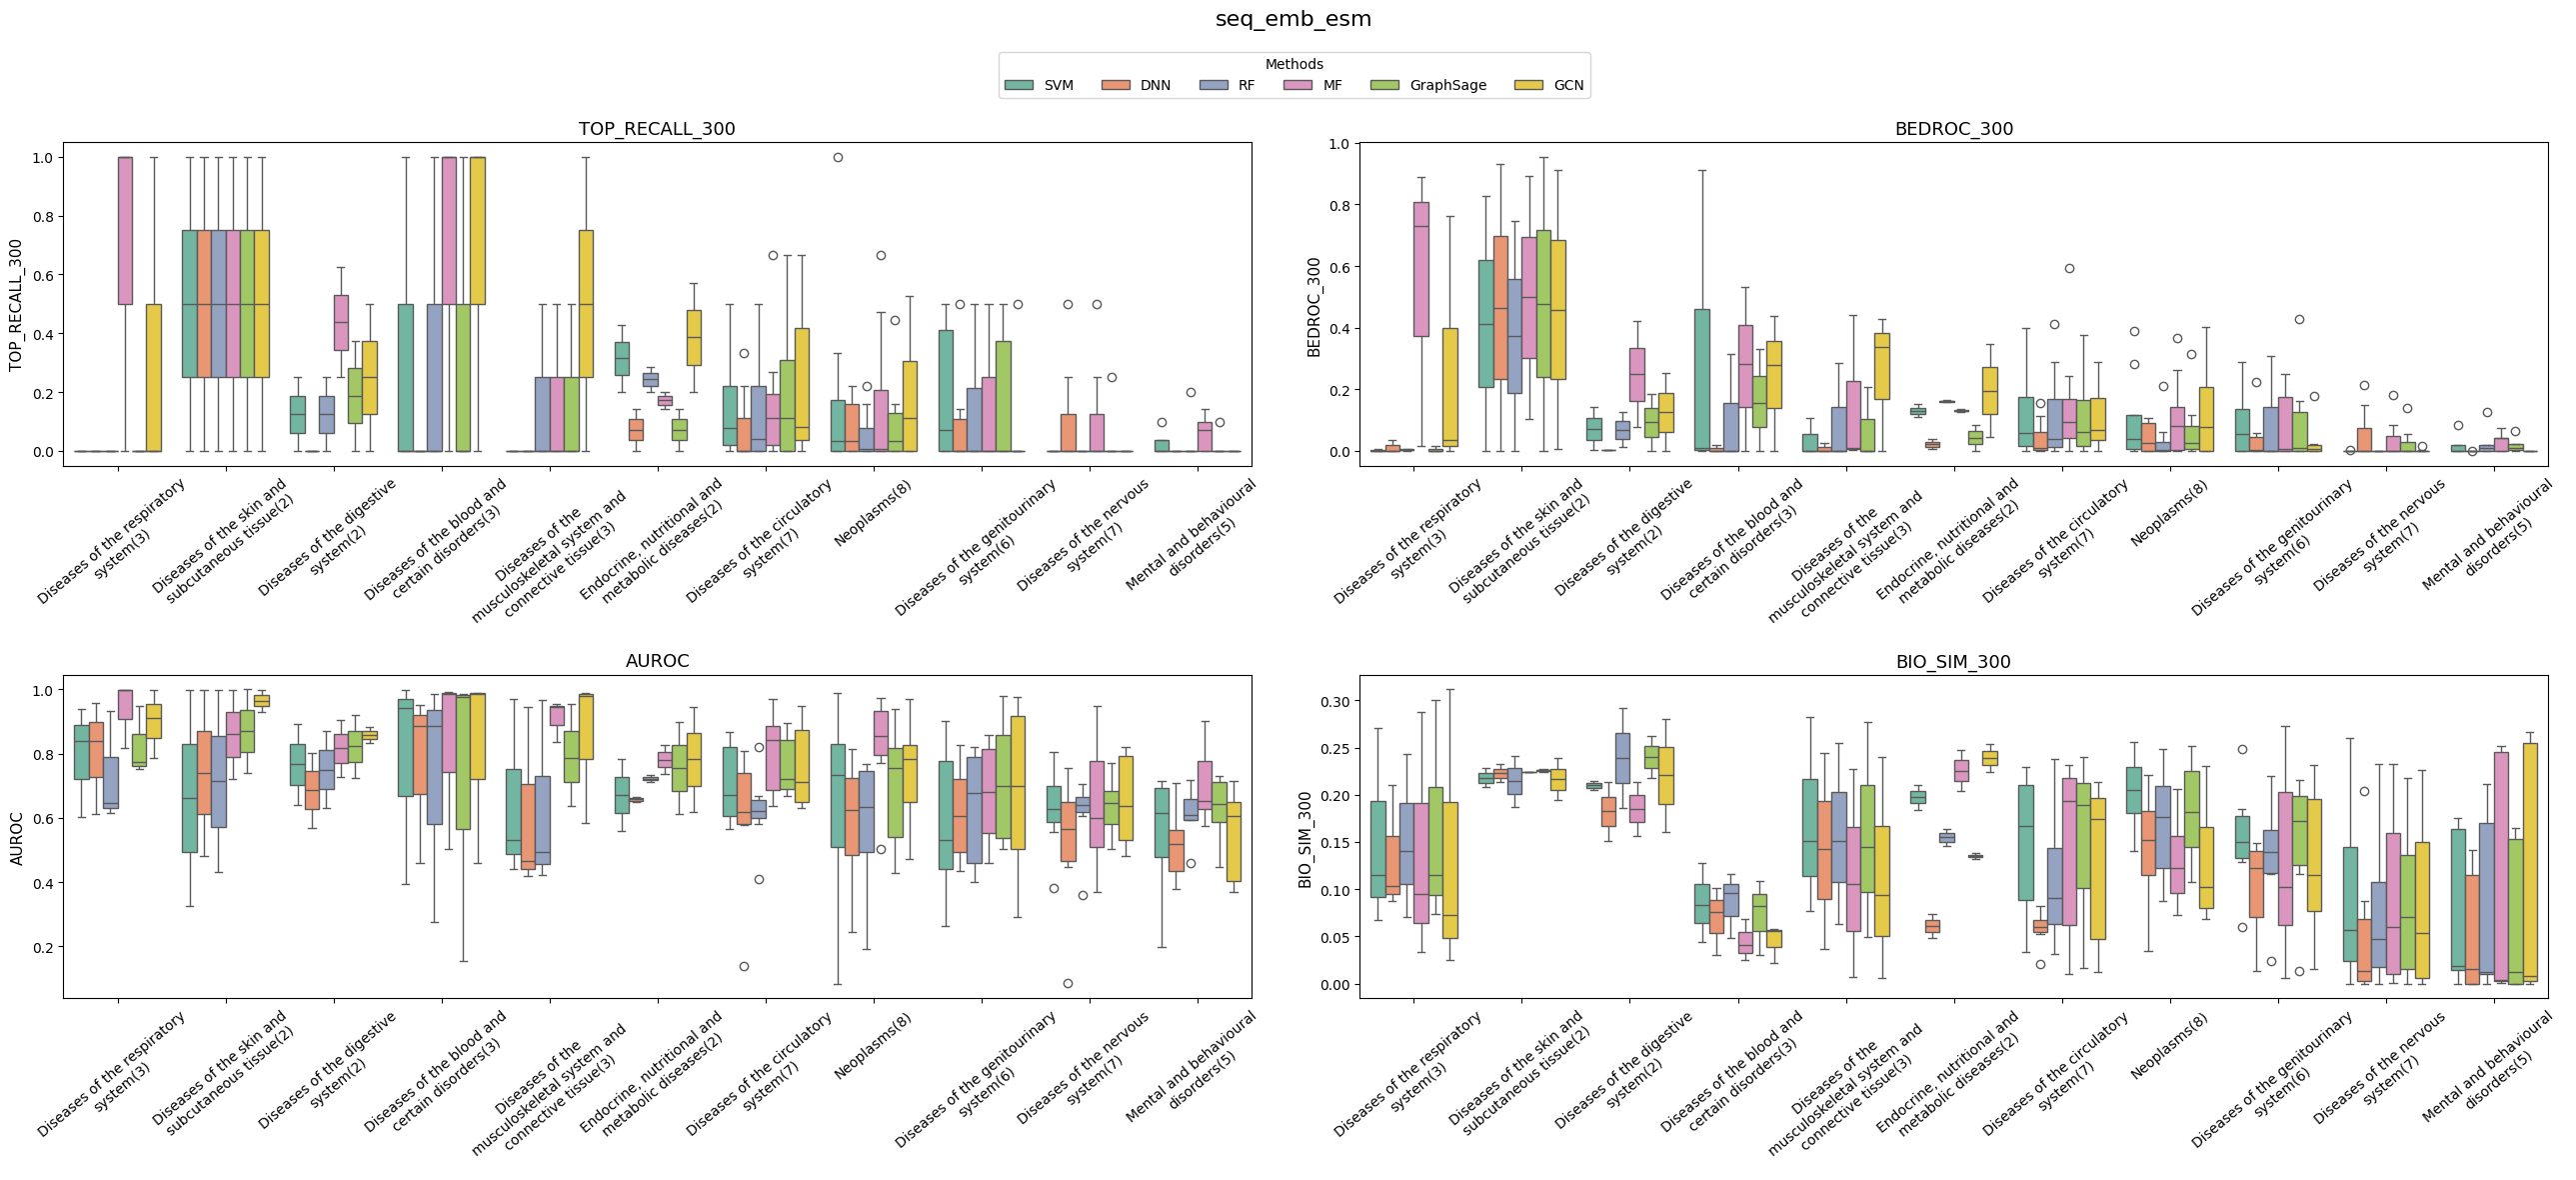

/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')
/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')
/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')
/tmp/ipykernel_3126948/2371515525.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=40, ha='center')


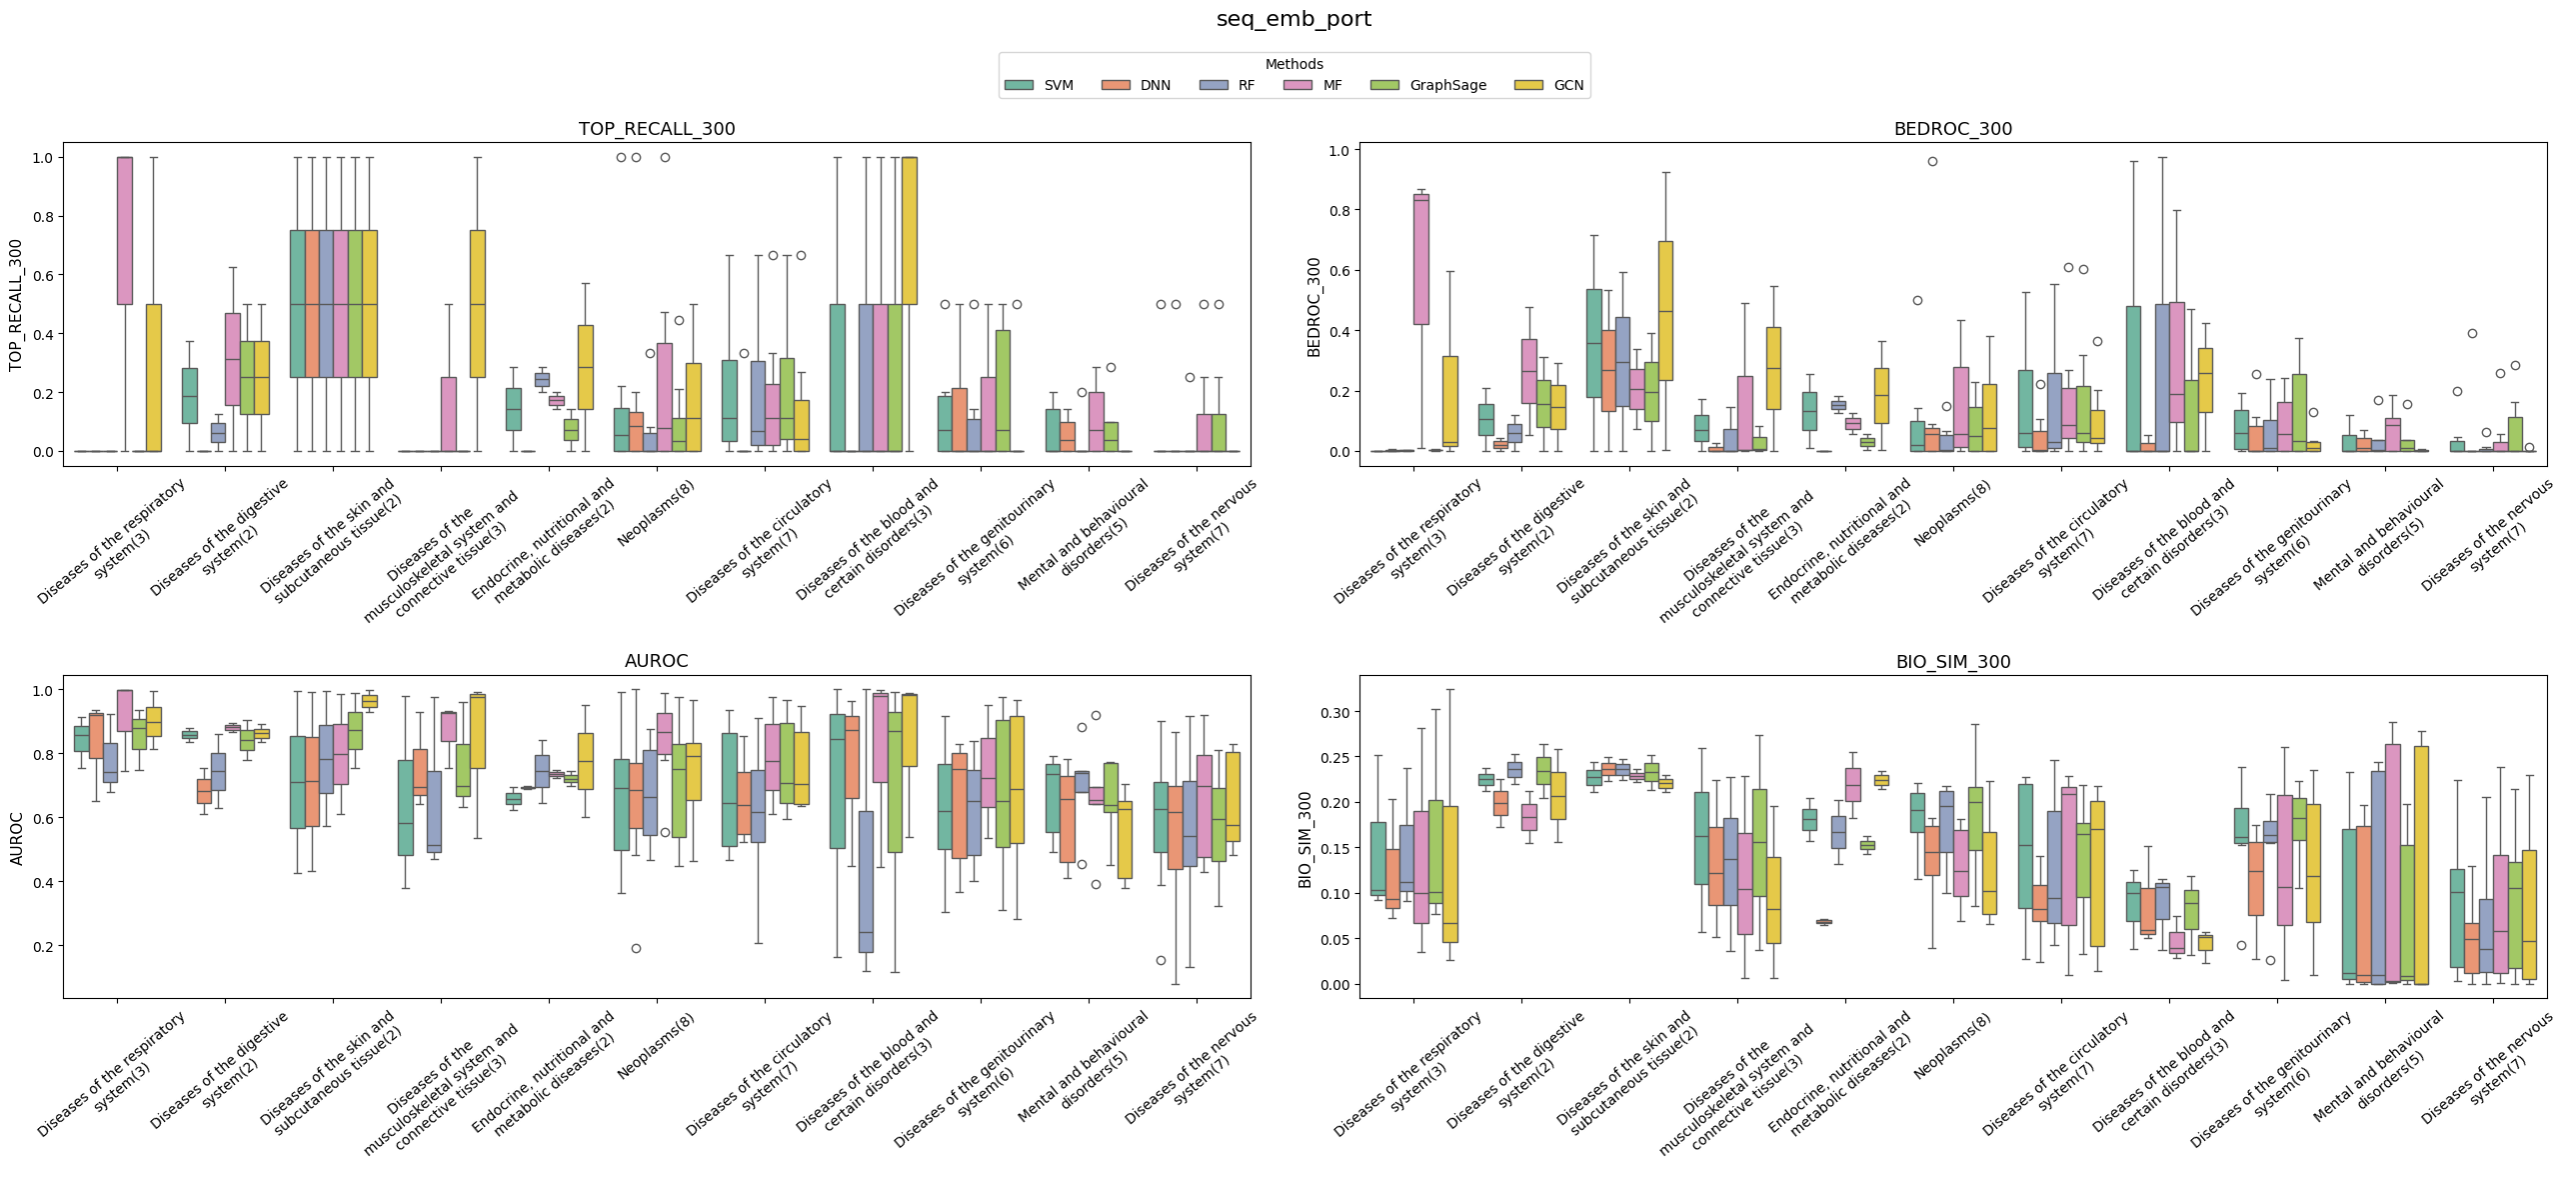

In [31]:
selected_features = ['ppi_emb_df','ppi_emb_dw', 'ppi_emb_n2v', 'literature_emb','seq_emb_esm', 'seq_emb_port']
models = ['df_gnn_occsvm_pred', '2019_nn_all_pred', '2019_rf_renamed_pred', '2019_mf_add_pred','graphsage', 'gcn']
model_name = ['SVM','DNN','RF','MF','GraphSage','GCN']
method_mapping = dict(zip(models,model_name))
for i, feature in enumerate(selected_features):
    subresults = merged_df[(merged_df['method']==feature)&(merged_df['setting'].isin(models))].copy()
    subresults['method'] = subresults['setting'].map(method_mapping)
    plot_metrics_boxplots_big(feature, subresults, selected_metrics,model_name)
    

In [ ]:
# Selected (setting, method) pairs
selected_pairs = [('df_gnn_occsvm_pred','ppi_emb_n2v'),
                  ('df_gnn_occsvm_pred','Graph_sage'),
                  ('df_gnn_occsvm_pred','GCNs'),
            ('2019_nn_all_pred','ppi_emb_n2v'),
            ('2019_rf_renamed_pred','ppi_emb_n2v'),
            ('2019_mf_bag_2_pred','uniport_ppi_2019')]

# Extract subset
subresults = (merged_df.set_index(['setting', 'method']).loc[selected_pairs].reset_index())

# Mapping from selected_pairs → new method names
method_mapping = dict(zip(selected_pairs,['svm','graph_sage','gcn','dnn','rf','mf']))

# Apply mapping
subresults['method'] = [method_mapping[(row['setting'], row['method'])]for _, row in subresults.iterrows()]

# for metric in ['top_recall_300','top_recall_10%', 
#                'auroc', 'bedroc_1','bedroc_5', 'bedroc_10',
#                'succ_5%','succ_10%',
#                'w_recall_5%',  'w_recall_10%', 
#                'cutoff_0.11%','cutoff_0.22%']:
for metric in ['top_recall_150', 'top_recall_300',
               'succ_150', 'succ_300',  
               'bedroc_150','bedroc_300', 'auroc',
               'bio_sim_300','bio_sim_150' ]:
    plot_metric_boxplot(subresults, metric,['svm','graph_sage','gcn','mf','rf','dnn'])

## fusion

In [ ]:
# selected_features = ['early_fused', 'early_fused_ppi', 'late_fused', 'late_fused_ppi','mid_fused', 'mid_fused_ppi', 'mid_geo_fused_ppi',
#        'mid_linear_fused', 'mid_linear_fused_ppi','mid_geo_fused']
selected_features = ['ppi_emb_dw','early_fused', 'late_fused', 'mid_fused','mid_linear_fused','mid_geo_fused']
subresults = merged_df[(merged_df['setting']=='df_gnn_occsvm_pred')&(merged_df['method'].isin(selected_features))]

# for metric in ['top_recall_300','top_recall_10%', 
#                'auroc', 'bedroc_1','bedroc_5', 'bedroc_10',
#                'succ_5%','succ_10%',
#                'w_recall_5%',  'w_recall_10%', 
#                'cutoff_0.11%','cutoff_0.22%']:
for metric in selected_metrics:
    plot_metric_boxplot(subresults, metric,['early_fused', 'mid_linear_fused', 'mid_geo_fused','late_fused','ppi_emb_dw'])


In [ ]:
selected_features = ['ppi_emb_dw','early_fused', 'early_fused_ppi', 'late_fused', 'late_fused_ppi','mid_fused', 'mid_fused_ppi', 'mid_geo_fused_ppi',
       'mid_linear_fused', 'mid_linear_fused_ppi','mid_geo_fused']
# selected_features = ['ppi_emb_dw','early_fused', 'late_fused', 'mid_fused','mid_linear_fused','mid_geo_fused']
subresults = merged_df[(merged_df['setting']=='df_gnn_occsvm_pred')&(merged_df['method'].isin(selected_features))]

for metric in ['top_recall_300','top_recall_10%', 
               'auroc', 'bedroc_1','bedroc_5', 'bedroc_10',
               'succ_5%','succ_10%',
               'w_recall_5%',  'w_recall_10%', 
               'cutoff_0.11%','cutoff_0.22%']:
    plot_metric_boxplot(subresults, metric,['early_fused_ppi', 'mid_linear_fused_ppi', 'mid_geo_fused_ppi','late_fused_ppi','ppi_emb_dw'])


In [ ]:
selected_features = ['ppi_emb_dw','early_fused', 'early_fused_ppi', 'late_fused', 'late_fused_ppi','mid_fused', 'mid_fused_ppi', 'mid_geo_fused_ppi',
       'mid_linear_fused', 'mid_linear_fused_ppi','mid_geo_fused']

subresults = merged_df[(merged_df['setting']=='2019_nn_all_pred')&(merged_df['method'].isin(selected_features))]

for metric in ['top_recall_25', 'top_recall_300','top_recall_10%', 'top_recall_30%', 
               'auroc', 'bedroc_1','bedroc_5', 'bedroc_10', 'bedroc_30', 
               'succ_1%', 'w_recall_1%', 'succ_5%','succ_10%',
               'w_recall_5%',  'w_recall_10%', 
               'cutoff_0.11%','cutoff_0.22%']:
    plot_metric_boxplot(subresults, metric,['early_fused', 'mid_fused','late_fused','ppi_emb_dw'])


In [ ]:
selected_features = ['ppi_emb_dw','early_fused', 'early_fused_ppi', 'late_fused', 'late_fused_ppi','mid_fused', 'mid_fused_ppi', 'mid_geo_fused_ppi',
       'mid_linear_fused', 'mid_linear_fused_ppi','mid_geo_fused']

subresults = merged_df[(merged_df['setting']=='2019_nn_all_pred')&(merged_df['method'].isin(selected_features))]

for metric in ['top_recall_25', 'top_recall_300','top_recall_10%', 'top_recall_30%', 
               'auroc', 'bedroc_1','bedroc_5', 'bedroc_10', 'bedroc_30', 
               'succ_1%', 'w_recall_1%', 'succ_5%','succ_10%',
               'w_recall_5%',  'w_recall_10%', 
               'cutoff_0.11%','cutoff_0.22%']:
    plot_metric_boxplot(subresults, metric,['early_fused_ppi', 'mid_fused_ppi','late_fused_ppi','ppi_emb_dw'])
